##  Cell 0 - Package Installation

This cell installs all required Python packages for the EV routing project using `pip`.
The packages include:
- **OSMnx / NetworkX** – road network download and graph algorithms
- **NumPy / Pandas** – numerical and tabular data processing
- **Matplotlib** – plotting and visualisation
- **PyTorch** – Deep Q-Network training
- **GeoPandas / Shapely** – geospatial operations
- **Folium** – interactive map generation

>  **Run this cell once before any other cell and restart the kernel if this is your first run.**


In [1]:
import subprocess
import sys

packages = [
    "osmnx",
    "networkx",
    "numpy",
    "pandas",
    "matplotlib",
    "scikit-learn",
    "torch",
    "scipy",
    "geopandas",
    "shapely",
    "tqdm",
    "folium"
]

print("Installing required packages...")
for pkg in packages:
    print(f"  Installing {pkg}...", end=" ")
    result = subprocess.run(
        [sys.executable, "-m", "pip", "install", pkg, "-q"],
        capture_output=True
    )
    if result.returncode == 0:
        print("OK")
    else:
        print(f"FAILED — {result.stderr.decode()[:100]}")

print("\nAll installations complete. Restart kernel if this is your first run.")


Installing required packages...
  Installing osmnx... OK
  Installing networkx... OK
  Installing numpy... OK
  Installing pandas... OK
  Installing matplotlib... OK
  Installing scikit-learn... OK
  Installing torch... OK
  Installing scipy... OK
  Installing geopandas... OK
  Installing shapely... OK
  Installing tqdm... OK
  Installing folium... OK

All installations complete. Restart kernel if this is your first run.


## Cell 1 - Imports & Global Configuration

Imports all required libraries and sets up the global configuration for the project:

- Sets `numpy` and `random` seeds for reproducibility (`seed = 42`).
- Defines the **study area bounding box** (South LA / Inglewood / Downey area, ~15 km × 12 km).
- Hard-codes the **5 known EV charging station coordinates** used throughout the project.
- Declares file paths for PeMS traffic data, PeMS station metadata, the Kaggle EV charging CSV, and the output directory.

>  Update `PEMS_DATA_FILES`, `PEMS_META_FILE`, and `EV_STATIONS_FILE` to match your local file locations before running subsequent cells.


In [2]:
import os
import gzip
import warnings
import numpy as np
import pandas as pd
import networkx as nx
import osmnx as ox
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.stats import truncnorm
from collections import defaultdict
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
import random
from shapely.geometry import Point
import folium

warnings.filterwarnings("ignore")
np.random.seed(42)
random.seed(42)

print("=" * 60)
print("  EV Routing Project — IIT Kharagpur Design Lab")
print("=" * 60)

# ── STUDY AREA BOUNDING BOX ───────────────────────────────────
# Derived from the 5 consolidated charging station coordinates
# + 0.02 degree buffer on all sides
BBOX = {
    "north":  34.03,
    "south":  33.89,
    "east":  -118.09,
    "west":  -118.24
}

print(f"\nStudy Area Bounding Box (consolidated 5-charger area):")
print(f"  North : {BBOX['north']}")
print(f"  South : {BBOX['south']}")
print(f"  East  : {BBOX['east']}")
print(f"  West  : {BBOX['west']}")
print(f"  Approx span: ~15 km N-S, ~12 km E-W")
print(f"  This is roughly the South LA / Inglewood / Downey area")

# ── KNOWN CHARGER COORDINATES (your 5 consolidated stations) ──
KNOWN_CHARGER_COORDS = [
    (34.012362, -118.114786),
    (33.955456, -118.109125),
    (33.912233, -118.222732),
    (33.911204, -118.153220),
    (33.934067, -118.198528),
]

# PeMS 5-minute station data files (can be .txt or .txt.gz)
PEMS_DATA_FILES = {
    "2025-01-01": "d07_text_station_5min_2025_01_01.txt",
    "2025-01-15": "d07_text_station_5min_2025_01_15.txt",
    "2025-04-19": "d07_text_station_5min_2025_04_19.txt",
    "2025-07-04": "d07_text_station_5min_2025_07_04.txt",
    "2025-09-08": "d07_text_station_5min_2025_09_08.txt",
    "2025-11-26": "d07_text_station_5min_2025_11_26.txt",
}

# PeMS station metadata file
PEMS_META_FILE = "d07_text_meta_2023_12_22.txt"

# Kaggle EV charging station CSV
EV_STATIONS_FILE = "ev_charging_station_data.csv"

# Output directory for processed data and results
OUTPUT_DIR = "ev_routing_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"\nOutput directory: {OUTPUT_DIR}/")
print("\nConfiguration loaded. Proceed to Cell 3.")


  EV Routing Project — IIT Kharagpur Design Lab

Study Area Bounding Box (consolidated 5-charger area):
  North : 34.03
  South : 33.89
  East  : -118.09
  West  : -118.24
  Approx span: ~15 km N-S, ~12 km E-W
  This is roughly the South LA / Inglewood / Downey area

Output directory: ev_routing_outputs/

Configuration loaded. Proceed to Cell 3.


##  Cell 2 - Step 1: Road Network Download (OSMnx)

Downloads the **drivable road network** for the South LA study area from OpenStreetMap using the OSMnx library.

Key operations:
- Checks for a **cached GraphML file** and loads from disk if found (avoids re-downloading).
- If no cache exists, tries four progressively more robust download approaches (OSMnx 2.x format, 1.x keyword format, Shapely polygon, and centroid + radius fallback).
- **Projects** the graph to UTM coordinates for accurate distance calculations.
- Converts to an **undirected graph** to allow bidirectional routing.
- Builds two lookup structures:
  - `node_positions`: maps each node ID to its `(lat, lon)`.
  - `edge_lengths`: maps each `(u, v)` edge pair to its length in km.
  - `adjacency`: adjacency list for fast neighbour lookup.
- Runs a **sanity check** by snapping each of the 5 known charger coordinates to their nearest road nodes.


In [3]:
print("=" * 60)
print("  STEP 1: Downloading Road Network via OSMnx")
print("=" * 60)

import osmnx as ox
print(f"  OSMnx version: {ox.__version__}")

GRAPH_FILE = os.path.join(OUTPUT_DIR, "la_study_area.graphml")

if os.path.exists(GRAPH_FILE):
    print(f"\nFound cached graph at {GRAPH_FILE}")
    print("Loading from cache (skipping download)...")
    G_raw = ox.load_graphml(GRAPH_FILE)
    print(f"  Loaded: {len(G_raw.nodes)} nodes, {len(G_raw.edges)} edges")

else:
    print(f"\nDownloading road network...")
    print(f"  Bounding box: lat [{BBOX['south']}, {BBOX['north']}], "
          f"lon [{BBOX['west']}, {BBOX['east']}]")
    print(f"  Approx area : ~15 km x 12 km (South LA area)")
    print(f"  Expected time: 30-90 seconds on a normal connection")
    print(f"  Please wait...\n")

    # ── OSMnx version-safe download ────────────────────────────
    # Different OSMnx versions have different bbox argument formats.
    # We try each approach in order until one works.

    G_raw = None
    errors = []

    # Approach 1: OSMnx 2.0+ tuple format (west, south, east, north)
    try:
        print("  Trying OSMnx 2.0+ format (west, south, east, north)...")
        G_raw = ox.graph_from_bbox(
            bbox=(BBOX['west'], BBOX['south'], BBOX['east'], BBOX['north']),
            network_type='drive',
            simplify=True
        )
        print("  Approach 1 succeeded.")
    except Exception as e:
        errors.append(f"Approach 1 failed: {e}")
        print(f"  {errors[-1]}")

    # Approach 2: OSMnx 1.x keyword format (north, south, east, west)
    if G_raw is None:
        try:
            print("  Trying OSMnx 1.x keyword format...")
            G_raw = ox.graph_from_bbox(
                north=BBOX['north'],
                south=BBOX['south'],
                east=BBOX['east'],
                west=BBOX['west'],
                network_type='drive',
                simplify=True
            )
            print("  Approach 2 succeeded.")
        except Exception as e:
            errors.append(f"Approach 2 failed: {e}")
            print(f"  {errors[-1]}")

    # Approach 3: Build polygon manually and use graph_from_polygon
    if G_raw is None:
        try:
            print("  Trying manual polygon approach...")
            from shapely.geometry import box as shapely_box
            polygon = shapely_box(
                BBOX['west'],   # minx
                BBOX['south'],  # miny
                BBOX['east'],   # maxx
                BBOX['north']   # maxy
            )
            G_raw = ox.graph_from_polygon(
                polygon,
                network_type='drive',
                simplify=True
            )
            print("  Approach 3 succeeded.")
        except Exception as e:
            errors.append(f"Approach 3 failed: {e}")
            print(f"  {errors[-1]}")

    # Approach 4: Use centroid point + radius (most robust fallback)
    if G_raw is None:
        try:
            print("  Trying point + radius approach (most robust)...")
            center_lat = (BBOX['north'] + BBOX['south']) / 2   # ~33.96
            center_lon = (BBOX['east']  + BBOX['west'])  / 2   # ~-118.165
            # 8 km radius covers the entire bounding box
            G_raw = ox.graph_from_point(
                (center_lat, center_lon),
                dist=8000,   # meters
                network_type='drive',
                simplify=True
            )
            print("  Approach 4 succeeded.")
        except Exception as e:
            errors.append(f"Approach 4 failed: {e}")
            print(f"  {errors[-1]}")

    if G_raw is None:
        print("\n  ALL APPROACHES FAILED. Error log:")
        for err in errors:
            print(f"    {err}")
        print("\n  Possible fixes:")
        print("  1. Check your internet connection")
        print("  2. Try running again (OSM servers occasionally time out)")
        print("  3. Run: pip install osmnx --upgrade")
        raise RuntimeError("Could not download road network. See errors above.")

    print(f"\n  Raw graph: {len(G_raw.nodes):,} nodes, {len(G_raw.edges):,} edges")

    print(f"  Saving to {GRAPH_FILE} for future use...")
    ox.save_graphml(G_raw, GRAPH_FILE)
    print(f"  Saved. Next run will load from cache instantly.")

# ── Project to UTM for accurate distance calculations ─────────
print("\nProjecting graph to UTM coordinate system...")
G_proj = ox.project_graph(G_raw)
print(f"  Projected: {len(G_proj.nodes):,} nodes, {len(G_proj.edges):,} edges")

# ── Convert to undirected for routing ─────────────────────────
print("\nConverting to undirected graph...")
# G = ox.get_undirected(G_proj)
G = nx.Graph(G_proj)
print(f"  Undirected: {len(G.nodes):,} nodes, {len(G.edges):,} edges")

# ── Extract node lat/lon positions from original (unprojected) graph
print("\nExtracting node positions...")
node_positions = {}
for node_id, data in G_raw.nodes(data=True):
    if 'y' in data and 'x' in data:
        node_positions[node_id] = (float(data['y']), float(data['x']))

print(f"  Node positions extracted: {len(node_positions):,}")

# ── Edge lengths ──────────────────────────────────────────────
print("\nBuilding edge length table...")
edge_lengths = {}
missing_length = 0
for u, v, data in G.edges(data=True):
    length_m = data.get('length', None)
    if length_m is None:
        # Estimate from coordinates if available
        missing_length += 1
        length_m = 100.0   # default 100m fallback
    length_km = float(length_m) / 1000.0
    edge_lengths[(u, v)] = length_km
    edge_lengths[(v, u)] = length_km

print(f"  Edge lengths computed: {len(edge_lengths):,} entries")
if missing_length > 0:
    print(f"  Edges missing length (used 100m fallback): {missing_length}")

# ── Adjacency ─────────────────────────────────────────────────
print("\nBuilding adjacency structure...")
adjacency = defaultdict(list)
for u, v in G.edges():
    if v not in adjacency[u]:
        adjacency[u].append(v)
    if u not in adjacency[v]:
        adjacency[v].append(u)

node_list   = list(G.nodes())
avg_degree  = np.mean([len(adjacency[n]) for n in node_list])

print(f"  Adjacency built: {len(node_list):,} nodes")
print(f"  Average node degree: {avg_degree:.2f}")

# ── Quick sanity check ────────────────────────────────────────
print("\n  Sanity check — verifying graph covers charger locations:")
for i, (clat, clon) in enumerate(KNOWN_CHARGER_COORDS):
    try:
        nearest = ox.nearest_nodes(G_raw, X=clon, Y=clat)
        nlat, nlon = node_positions.get(nearest, ('?', '?'))
        print(f"  Charger {i+1}: ({clat:.4f}, {clon:.4f}) "
              f"→ nearest node {nearest} at ({nlat:.4f}, {nlon:.4f})")
    except Exception as e:
        print(f"  Charger {i+1}: Could not snap — {e}")

print("\nStep 1 complete. Proceed to Cell 4.")


  STEP 1: Downloading Road Network via OSMnx
  OSMnx version: 2.1.0

Found cached graph at ev_routing_outputs\la_study_area.graphml
Loading from cache (skipping download)...
  Loaded: 11147 nodes, 30693 edges

Projecting graph to UTM coordinate system...
  Projected: 11,147 nodes, 30,693 edges

Converting to undirected graph...
  Undirected: 11,147 nodes, 16,991 edges

Extracting node positions...
  Node positions extracted: 11,147

Building edge length table...
  Edge lengths computed: 33,976 entries

Building adjacency structure...
  Adjacency built: 11,147 nodes
  Average node degree: 3.05

  Sanity check — verifying graph covers charger locations:
  Charger 1: (34.0124, -118.1148) → nearest node 122555853 at (34.0126, -118.1153)
  Charger 2: (33.9555, -118.1091) → nearest node 123039505 at (33.9553, -118.1087)
  Charger 3: (33.9122, -118.2227) → nearest node 123285928 at (33.9126, -118.2230)
  Charger 4: (33.9112, -118.1532) → nearest node 123051302 at (33.9113, -118.1529)
  Charge

##  Cell 3 - Step 2: PeMS Station Metadata Loading

Reads the **Caltrans PeMS station metadata file** to identify which traffic sensors fall within the study area bounding box.

Key operations:
- Reads the tab-separated metadata file with 18 standard PeMS columns.
- Auto-detects and normalises column names (latitude, longitude, station ID, type, lanes).
- Drops rows with missing or non-numeric coordinates.
- **Filters** stations to those inside the `BBOX` (south LA study region).
- Saves the filtered metadata to `ev_routing_outputs/pems_meta_study_area.csv`.
- Builds `pems_station_coords`: a dict mapping `station_id → (lat, lon)` for all in-scope sensors.


In [4]:
print("=" * 60)
print("  STEP 2: Loading PeMS Station Metadata")
print("=" * 60)

print(f"\nReading metadata file: {PEMS_META_FILE}")

# PeMS metadata columns (standard format)
META_COLS = [
    'ID', 'Fwy', 'Dir', 'District', 'County', 'City',
    'State_PM', 'Abs_PM', 'Latitude', 'Longitude',
    'Length', 'Type', 'Lanes', 'Name',
    'User_ID_1', 'User_ID_2', 'User_ID_3', 'User_ID_4'
]

try:
    meta_df = pd.read_csv(
        PEMS_META_FILE,
        sep='\t',
        header=0,
        names=META_COLS if pd.read_csv(PEMS_META_FILE, sep='\t', nrows=0).shape[1] == len(META_COLS) else None,
        low_memory=False
    )
except Exception:
    # Try comma-separated
    meta_df = pd.read_csv(PEMS_META_FILE, low_memory=False)

print(f"  Raw metadata: {len(meta_df)} stations")
print(f"  Columns: {list(meta_df.columns)}")

# Standardize column names to expected format
col_map = {}
for col in meta_df.columns:
    cl = col.strip().lower()
    if 'lat' in cl:
        col_map[col] = 'Latitude'
    elif 'lon' in cl:
        col_map[col] = 'Longitude'
    elif cl == 'id' or cl == 'station_id':
        col_map[col] = 'ID'
    elif 'type' in cl:
        col_map[col] = 'Type'
    elif 'lane' in cl:
        col_map[col] = 'Lanes'

meta_df = meta_df.rename(columns=col_map)

# Drop rows with missing lat/lon
meta_df = meta_df.dropna(subset=['Latitude', 'Longitude'])
meta_df['Latitude']  = pd.to_numeric(meta_df['Latitude'],  errors='coerce')
meta_df['Longitude'] = pd.to_numeric(meta_df['Longitude'], errors='coerce')
meta_df = meta_df.dropna(subset=['Latitude', 'Longitude'])

print(f"  After cleaning: {len(meta_df)} stations with valid coordinates")

# ── Filter to study area bounding box ─────────────────────────
meta_bbox = meta_df[
    (meta_df['Latitude']  >= BBOX['south']) &
    (meta_df['Latitude']  <= BBOX['north']) &
    (meta_df['Longitude'] >= BBOX['west'])  &
    (meta_df['Longitude'] <= BBOX['east'])
].copy()

print(f"  Stations in study area bounding box: {len(meta_bbox)}")

if len(meta_bbox) == 0:
    print("\n  WARNING: No stations found in bounding box.")
    print("  Check that PEMS_META_FILE is correct and coordinates match.")
else:
    print(f"\n  Station ID range: {meta_bbox['ID'].min()} to {meta_bbox['ID'].max()}")
    if 'Type' in meta_bbox.columns:
        print(f"  Station types: {meta_bbox['Type'].value_counts().to_dict()}")

    # Save filtered metadata
    meta_out = os.path.join(OUTPUT_DIR, "pems_meta_study_area.csv")
    meta_bbox.to_csv(meta_out, index=False)
    print(f"  Saved filtered metadata → {meta_out}")

# Create lookup: station_id → (lat, lon)
pems_station_coords = {}
for _, row in meta_bbox.iterrows():
    pems_station_coords[row['ID']] = (row['Latitude'], row['Longitude'])

print(f"\nPeMS station coordinate lookup built: {len(pems_station_coords)} entries")
print("\nStep 2 complete. Proceed to Cell 5.")


  STEP 2: Loading PeMS Station Metadata

Reading metadata file: d07_text_meta_2023_12_22.txt
  Raw metadata: 4888 stations
  Columns: ['ID', 'Fwy', 'Dir', 'District', 'County', 'City', 'State_PM', 'Abs_PM', 'Latitude', 'Longitude', 'Length', 'Type', 'Lanes', 'Name', 'User_ID_1', 'User_ID_2', 'User_ID_3', 'User_ID_4']
  After cleaning: 4883 stations with valid coordinates
  Stations in study area bounding box: 372

  Station ID range: 715918 to 776981
  Station types: {'ML': 155, 'OR': 87, 'FR': 56, 'HV': 53, 'FF': 20, 'CD': 1}
  Saved filtered metadata → ev_routing_outputs\pems_meta_study_area.csv

PeMS station coordinate lookup built: 372 entries

Step 2 complete. Proceed to Cell 5.


##  Cell 4 - Step 3: PeMS 5-Minute Traffic Data Loading

Loads six days of **Caltrans PeMS 5-minute interval speed data** representing different traffic conditions:

| Date | Type |
|------|------|
| 2025-01-01 | Holiday |
| 2025-01-15 | Weekday (Winter) |
| 2025-04-19 | Weekday (Spring) |
| 2025-07-04 | Holiday |
| 2025-09-08 | Weekday (Fall) |
| 2025-11-26 | Holiday Eve |

Key operations:
- Supports both plain `.txt` and compressed `.txt.gz` files.
- Assigns the 12 standard PeMS column names; handles extra columns gracefully.
- **Filters rows** to only include stations inside the study area.
- Parses timestamps, extracts the hour slot (0–23), and cleans speed values.
- Converts speeds from **mph → km/h**.
- Combines all dates into a single `pems_combined` DataFrame and saves it.


In [5]:
print("=" * 60)
print("  STEP 3: Loading PeMS 5-Minute Traffic Data")
print("=" * 60)

# PeMS 5-minute data columns (standard format)
PEMS_5MIN_COLS = [
    'Timestamp', 'Station', 'District', 'Freeway', 'Direction',
    'Lane_Type', 'Station_Length', 'Samples', 'Pct_Observed',
    'Total_Flow', 'Avg_Occupancy', 'Avg_Speed'
]

all_records = []

for date_str, filename in PEMS_DATA_FILES.items():
    print(f"\n  Processing {date_str} ({filename})...")

    if not os.path.exists(filename):
        print(f"    FILE NOT FOUND: {filename} — skipping")
        continue

    # Handle both .gz and plain text
    try:
        if filename.endswith('.gz'):
            with gzip.open(filename, 'rt') as f:
                df = pd.read_csv(f, header=None, low_memory=False)
        else:
            df = pd.read_csv(filename, header=None, low_memory=False)

        # Assign column names to the columns we have
        n_cols = df.shape[1]
        if n_cols >= 12:
            df.columns = PEMS_5MIN_COLS[:12] + [f'extra_{i}' for i in range(n_cols - 12)]
        else:
            df.columns = PEMS_5MIN_COLS[:n_cols]

        print(f"    Raw rows: {len(df):,}")

        # Keep only stations in our study area
        study_station_ids = set(pems_station_coords.keys())
        df['Station'] = pd.to_numeric(df['Station'], errors='coerce')
        df = df[df['Station'].isin(study_station_ids)].copy()
        print(f"    Rows after station filter: {len(df):,}")

        if len(df) == 0:
            print(f"    WARNING: No matching stations for this date.")
            continue

        # Parse timestamp
        df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
        df = df.dropna(subset=['Timestamp'])

        # Extract hour slot (0-23)
        df['hour'] = df['Timestamp'].dt.hour

        # Clean speed column
        df['Avg_Speed'] = pd.to_numeric(df['Avg_Speed'], errors='coerce')
        df = df.dropna(subset=['Avg_Speed'])
        df = df[df['Avg_Speed'] > 0]

        # Add date label
        df['date'] = date_str
        df['date_type'] = {
            "2025-01-01": "holiday",
            "2025-01-15": "weekday_winter",
            "2025-04-19": "weekday_spring",
            "2025-07-04": "holiday",
            "2025-09-08": "weekday_fall",
            "2025-11-26": "holiday_eve"
        }.get(date_str, "unknown")

        all_records.append(df[['Station', 'hour', 'Avg_Speed', 'date', 'date_type']])
        print(f"    Clean rows retained: {len(df):,}")
        print(f"    Speed range: {df['Avg_Speed'].min():.1f} – {df['Avg_Speed'].max():.1f} mph")

    except Exception as e:
        print(f"    ERROR reading file: {e}")
        continue

if len(all_records) == 0:
    print("\nERROR: No PeMS data loaded. Check file paths and formats.")
    pems_combined = pd.DataFrame()
else:
    pems_combined = pd.concat(all_records, ignore_index=True)
    # Convert mph to km/h
    pems_combined['speed_kmh'] = pems_combined['Avg_Speed'] * 1.60934
    print(f"\nTotal records loaded: {len(pems_combined):,}")
    print(f"Stations covered: {pems_combined['Station'].nunique()}")
    print(f"Hour slots covered: {sorted(pems_combined['hour'].unique())}")
    print(f"Overall speed range: {pems_combined['speed_kmh'].min():.1f} – {pems_combined['speed_kmh'].max():.1f} km/h")

    out_path = os.path.join(OUTPUT_DIR, "pems_combined.csv")
    pems_combined.to_csv(out_path, index=False)
    print(f"\nSaved combined PeMS data → {out_path}")

print("\nStep 3 complete. Proceed to Cell 6.")


  STEP 3: Loading PeMS 5-Minute Traffic Data

  Processing 2025-01-01 (d07_text_station_5min_2025_01_01.txt)...
    Raw rows: 1,407,744
    Rows after station filter: 107,136
    Clean rows retained: 59,904
    Speed range: 8.1 – 79.7 mph

  Processing 2025-01-15 (d07_text_station_5min_2025_01_15.txt)...
    Raw rows: 1,407,744
    Rows after station filter: 107,136
    Clean rows retained: 59,904
    Speed range: 6.0 – 79.0 mph

  Processing 2025-04-19 (d07_text_station_5min_2025_04_19.txt)...
    Raw rows: 1,407,744
    Rows after station filter: 107,136
    Clean rows retained: 59,904
    Speed range: 4.5 – 81.2 mph

  Processing 2025-07-04 (d07_text_station_5min_2025_07_04.txt)...
    Raw rows: 1,407,744
    Rows after station filter: 107,136
    Clean rows retained: 59,904
    Speed range: 13.3 – 81.3 mph

  Processing 2025-09-08 (d07_text_station_5min_2025_09_08.txt)...
    Raw rows: 1,407,744
    Rows after station filter: 107,136
    Clean rows retained: 59,904
    Speed range:

## Cell 5 - Step 4: Hourly Speed Distributions

Computes **truncated-normal speed distribution parameters** for every `(station_id, hour)` pair from the loaded PeMS data.

Parameters computed per pair:
- `mean_v` – mean speed (km/h)
- `std_v` – standard deviation
- `min_v` – 5th percentile (practical lower bound)
- `max_v` – 95th percentile (practical upper bound)

Key operations:
- Clamps values to physically realistic bounds: 5–130 km/h.
- Prints an hourly summary table averaged across all stations.
- Saves the distribution table to `ev_routing_outputs/speed_distributions.csv`.
- Defines **fallback distributions** for all 24 hours in case PeMS data is unavailable (rush-hour, midday, evening, night profiles).


In [6]:
print("=" * 60)
print("  STEP 4: Building Speed Distributions Per Hour Slot")
print("=" * 60)

# For each (station_id, hour) we compute:
# mean, std, min, max speed in km/h
# These become the truncated normal parameters for our environment

speed_dist_params = {}   # (station_id, hour) → (mean, std, vmin, vmax)

if len(pems_combined) == 0:
    print("No PeMS data available. Using synthetic fallback distributions.")
    USE_REAL_SPEED = False
else:
    USE_REAL_SPEED = True
    print(f"\nComputing distributions for each (station, hour) combination...")

    grouped = pems_combined.groupby(['Station', 'hour'])['speed_kmh']

    n_computed = 0
    for (station_id, hour), speeds in grouped:
        if len(speeds) < 3:
            continue

        mean_v = float(speeds.mean())
        std_v  = float(speeds.std())
        min_v  = float(speeds.quantile(0.05))   # 5th percentile as practical min
        max_v  = float(speeds.quantile(0.95))   # 95th percentile as practical max

        # Clamp to physically reasonable bounds
        min_v = max(min_v, 5.0)
        max_v = min(max_v, 130.0)
        std_v = max(std_v, 1.0)   # avoid zero std

        speed_dist_params[(station_id, hour)] = (mean_v, std_v, min_v, max_v)
        n_computed += 1

    print(f"  Computed distributions for {n_computed} (station, hour) pairs")

    # ── Summarize by hour (averaged across stations) ───────────
    print("\n  Hourly average speed summary (across all stations):")
    print(f"  {'Hour':>5} | {'Mean (km/h)':>12} | {'Std':>7} | {'Min':>7} | {'Max':>7}")
    print("  " + "-" * 50)

    for hour in range(24):
        hour_params = [v for (s, h), v in speed_dist_params.items() if h == hour]
        if hour_params:
            means = [p[0] for p in hour_params]
            stds  = [p[1] for p in hour_params]
            mins  = [p[2] for p in hour_params]
            maxs  = [p[3] for p in hour_params]
            print(f"  {hour:>5} | {np.mean(means):>12.1f} | "
                  f"{np.mean(stds):>7.1f} | "
                  f"{np.mean(mins):>7.1f} | "
                  f"{np.mean(maxs):>7.1f}")

    # Save
    dist_records = []
    for (station_id, hour), (mean_v, std_v, min_v, max_v) in speed_dist_params.items():
        dist_records.append({
            'station_id': station_id,
            'hour': hour,
            'mean_kmh': mean_v,
            'std_kmh': std_v,
            'min_kmh': min_v,
            'max_kmh': max_v
        })
    dist_df = pd.DataFrame(dist_records)
    dist_out = os.path.join(OUTPUT_DIR, "speed_distributions.csv")
    dist_df.to_csv(dist_out, index=False)
    print(f"\n  Saved speed distribution table → {dist_out}")

# ── Fallback distributions if PeMS data unavailable ───────────
FALLBACK_SPEED_PARAMS = {}
for hour in range(24):
    if 7 <= hour <= 9 or 16 <= hour <= 18:
        params = (40.0, 15.0, 10.0, 70.0)    # rush hour (km/h)
    elif 10 <= hour <= 15:
        params = (65.0, 10.0, 30.0, 90.0)    # midday
    elif 19 <= hour <= 21:
        params = (75.0, 8.0, 45.0, 100.0)    # evening
    else:
        params = (90.0, 8.0, 60.0, 110.0)    # night / early morning
    FALLBACK_SPEED_PARAMS[hour] = params

print(f"\nFallback speed distributions defined for all 24 hours.")
print(f"\nStep 4 complete. Proceed to Cell 7.")


  STEP 4: Building Speed Distributions Per Hour Slot

Computing distributions for each (station, hour) combination...
  Computed distributions for 4992 (station, hour) pairs

  Hourly average speed summary (across all stations):
   Hour |  Mean (km/h) |     Std |     Min |     Max
  --------------------------------------------------
      0 |        106.9 |     2.8 |   102.2 |   110.0
      1 |        106.6 |     2.8 |   102.4 |   109.8
      2 |        106.7 |     2.7 |   102.7 |   109.7
      3 |        106.4 |     2.9 |   101.8 |   109.3
      4 |        107.2 |     2.7 |   103.0 |   110.4
      5 |        107.4 |     3.7 |   101.0 |   112.0
      6 |        101.2 |     6.4 |    89.4 |   108.2
      7 |         95.2 |     9.7 |    79.1 |   107.1
      8 |         92.8 |     9.7 |    78.6 |   106.3
      9 |         94.5 |     7.6 |    82.9 |   105.0
     10 |         95.5 |     6.2 |    85.4 |   103.4
     11 |         94.5 |     6.1 |    84.2 |   102.2
     12 |         93.4 |     

##  Cell 6 - Step 5: EV Charging Station Data Loading

Loads EV charging station data from the **Kaggle EV charging station CSV** and builds a unified `charger_list`.

Key operations:
- Attempts to read the Kaggle CSV, auto-detects latitude/longitude columns, and filters to the study area bounding box.
- If the CSV is unavailable, falls back to the **5 hard-coded known charger coordinates**.
- Assigns charger types (`DC_Fast` vs `AC_Slow`), maximum charge rates (kW), and costs (USD/kWh).
- Saves the final charger list to `ev_routing_outputs/charger_list.csv`.

> Charger costs: DC Fast = $0.35/kWh @ 50 kW, AC Slow = $0.15/kWh @ 7.2 kW.


In [7]:
print("=" * 60)
print("  STEP 5: Loading EV Charging Station Data")
print("=" * 60)

print(f"\nKnown charger coordinates: {len(KNOWN_CHARGER_COORDS)}")

# Try loading the full Kaggle CSV
charger_df = None

if os.path.exists(EV_STATIONS_FILE):
    print(f"\nReading Kaggle dataset: {EV_STATIONS_FILE}")
    charger_df = pd.read_csv(EV_STATIONS_FILE, low_memory=False)
    print(f"  Raw rows: {len(charger_df):,}")
    print(f"  Columns: {list(charger_df.columns)[:15]}...")

    # Detect latitude and longitude columns
    lat_col, lon_col = None, None
    for col in charger_df.columns:
        cl = col.strip().lower().replace(' ', '_')
        if 'lat' in cl and lat_col is None:
            lat_col = col
        if ('lon' in cl or 'lng' in cl) and lon_col is None:
            lon_col = col

    if lat_col and lon_col:
        print(f"  Detected: lat='{lat_col}', lon='{lon_col}'")
        charger_df = charger_df.rename(columns={lat_col: 'Latitude', lon_col: 'Longitude'})
        charger_df['Latitude']  = pd.to_numeric(charger_df['Latitude'],  errors='coerce')
        charger_df['Longitude'] = pd.to_numeric(charger_df['Longitude'], errors='coerce')
        charger_df = charger_df.dropna(subset=['Latitude', 'Longitude'])

        # Filter to study area
        charger_df = charger_df[
            (charger_df['Latitude']  >= BBOX['south']) &
            (charger_df['Latitude']  <= BBOX['north']) &
            (charger_df['Longitude'] >= BBOX['west'])  &
            (charger_df['Longitude'] <= BBOX['east'])
        ].copy()
        print(f"  Stations in study area: {len(charger_df)}")
    else:
        print("  Could not auto-detect lat/lon columns. Using known coordinates only.")
        charger_df = None
else:
    print(f"  File not found: {EV_STATIONS_FILE}")
    print("  Using the 9 known coordinates directly.")

# ── Build final charger list ───────────────────────────────────
charger_list = []

if charger_df is not None and len(charger_df) > 0:
    print("\nBuilding charger list from CSV data...")

    # Detect charger type columns
    dc_col, l2_col = None, None
    for col in charger_df.columns:
        cl = col.strip().lower()
        if 'dc' in cl and 'fast' in cl:
            dc_col = col
        if 'level2' in cl or 'level_2' in cl or 'l2' in cl:
            l2_col = col

    for idx, row in charger_df.iterrows():
        lat = row['Latitude']
        lon = row['Longitude']

        # Determine charger type
        is_dc_fast = False
        if dc_col and pd.notna(row.get(dc_col)):
            try:
                is_dc_fast = int(row[dc_col]) > 0
            except Exception:
                pass

        charger_list.append({
            'latitude':      lat,
            'longitude':     lon,
            'charger_type':  'DC_Fast' if is_dc_fast else 'AC_Slow',
            'max_rate_kw':   50.0 if is_dc_fast else 7.2,
            'cost_per_kwh':  0.35 if is_dc_fast else 0.15,   # USD/kWh
        })

    print(f"  Built {len(charger_list)} charger entries from CSV")

else:
    print("\nBuilding charger list from known coordinates...")
    # Alternate DC Fast / AC Slow based on typical distribution
    for i, (lat, lon) in enumerate(KNOWN_CHARGER_COORDS):
        is_dc = (i % 3 == 0)    # every 3rd is DC fast — adjust if you know the real types
        charger_list.append({
            'latitude':      lat,
            'longitude':     lon,
            'charger_type':  'DC_Fast' if is_dc else 'AC_Slow',
            'max_rate_kw':   50.0 if is_dc else 7.2,
            'cost_per_kwh':  0.35 if is_dc else 0.15,
        })
    print(f"  Built {len(charger_list)} charger entries from known coordinates")

# Summary
dc_count = sum(1 for c in charger_list if c['charger_type'] == 'DC_Fast')
ac_count = len(charger_list) - dc_count
print(f"\n  DC Fast chargers : {dc_count}")
print(f"  AC Slow chargers : {ac_count}")

# Save charger list
charger_out_df = pd.DataFrame(charger_list)
charger_out    = os.path.join(OUTPUT_DIR, "charger_list.csv")
charger_out_df.to_csv(charger_out, index=False)
print(f"  Saved charger list → {charger_out}")

print("\nStep 5 complete. Proceed to Cell 8.")


  STEP 5: Loading EV Charging Station Data

Known charger coordinates: 5

Reading Kaggle dataset: ev_charging_station_data.csv
  Raw rows: 1,317,750
  Columns: ['timestamp', 'station_id', 'station_name', 'network', 'city', 'state', 'latitude', 'longitude', 'location_type', 'charger_type', 'power_output_kw', 'amenities_nearby', 'ports_total', 'ports_available', 'ports_occupied']...
  Detected: lat='latitude', lon='longitude'
  Stations in study area: 43925

Building charger list from CSV data...
  Built 43925 charger entries from CSV

  DC Fast chargers : 0
  AC Slow chargers : 43925
  Saved charger list → ev_routing_outputs\charger_list.csv

Step 5 complete. Proceed to Cell 8.


##  Cell 7 - Step 6: Snapping Real-World Data to the Road Graph

Maps real-world sensor and charger coordinates onto the **abstract routing graph**.

Key operations:
- Defines `nearest_node(G_raw, lat, lon)` using `ox.nearest_nodes`.
- **Snaps PeMS sensors to edges**: for each sensor, finds the nearest road edge (skips sensors > 500 m away) and assigns its speed distribution parameters to that edge for every hour slot.
- If multiple sensors map to the same edge, their distributions are **averaged**.
- Defines `get_speed_params(u, v, hour)`: returns `(mean, std, vmin, vmax)` for any edge at any hour, falling back to synthetic distributions when no real data exists.


In [8]:
print("=" * 60)
print("  STEP 6: Snapping Real-World Data to Road Graph")
print("=" * 60)

def nearest_node(G_raw, lat, lon):
    """Find the nearest OSMnx graph node to a (lat, lon) coordinate."""
    return ox.nearest_nodes(G_raw, X=lon, Y=lat)

# ── Snap PeMS sensors to nearest graph edges ──────────────────
print("\nSnapping PeMS sensors to nearest road edges...")

pems_edge_speed_params = {}
# edge (u,v) → {hour → (mean, std, min, max)} in km/h

if USE_REAL_SPEED and len(pems_station_coords) > 0:
    n_snapped = 0
    for station_id, (lat, lon) in pems_station_coords.items():
        try:
            # Find nearest edge
            nearest = ox.nearest_edges(G_raw, X=lon, Y=lat, return_dist=True)
            if isinstance(nearest, tuple):
                edge, dist = nearest
            else:
                edge = nearest
                dist = None

            u, v, key = edge if len(edge) == 3 else (*edge, 0)

            # Skip if too far (>500m — sensor is off our road network)
            if dist and dist > 500:
                continue

            edge_key = (u, v)

            # Assign speed distribution for each hour
            for hour in range(24):
                params = speed_dist_params.get((station_id, hour))
                if params is None:
                    params = FALLBACK_SPEED_PARAMS[hour]

                if edge_key not in pems_edge_speed_params:
                    pems_edge_speed_params[edge_key] = {}
                    pems_edge_speed_params[(v, u)] = {}

                # Average if multiple sensors on same edge
                if hour in pems_edge_speed_params[edge_key]:
                    old = pems_edge_speed_params[edge_key][hour]
                    new = tuple((o + n) / 2 for o, n in zip(old, params))
                    pems_edge_speed_params[edge_key][hour] = new
                    pems_edge_speed_params[(v, u)][hour]  = new
                else:
                    pems_edge_speed_params[edge_key][hour] = params
                    pems_edge_speed_params[(v, u)][hour]  = params

            n_snapped += 1

        except Exception as e:
            continue

    print(f"  PeMS sensors snapped to edges: {n_snapped}")
    print(f"  Edges with real speed data: {len(pems_edge_speed_params) // 2}")

else:
    print("  No real PeMS data — all edges will use fallback distributions.")
    pems_edge_speed_params = {}

# ── Function to get speed params for any edge ─────────────────
def get_speed_params(u, v, hour):
    """
    Returns (mean, std, vmin, vmax) in km/h for edge (u,v) at given hour.
    Falls back to synthetic distribution if no real data for this edge.
    """
    params = pems_edge_speed_params.get((u, v), {}).get(hour, None)
    if params is None:
        params = FALLBACK_SPEED_PARAMS.get(hour, (50.0, 10.0, 20.0, 80.0))
    return params

print(f"\nSpeed lookup function defined.")
print(f"  Edges with real data: {len(pems_edge_speed_params) // 2}")
print(f"  Remaining edges use fallback distributions.")

print("\nStep 6 complete. Proceed to Cell 9.")


  STEP 6: Snapping Real-World Data to Road Graph

Snapping PeMS sensors to nearest road edges...
  PeMS sensors snapped to edges: 372
  Edges with real speed data: 130

Speed lookup function defined.
  Edges with real data: 130
  Remaining edges use fallback distributions.

Step 6 complete. Proceed to Cell 9.


##  Cell 8 - Step 7: Building the Condensed Abstract Routing Graph

Constructs the **key-node graph** used by the MDP and DQN agents, reducing the full OSMnx road graph to a tractable abstract problem.

Key operations:
- **Snaps all 5 chargers** to their nearest road nodes; deduplicates if two chargers map to the same node.
- Enforces a realistic DC Fast / AC Slow charger mix.
- Selects **depot** as the centroid of all charger locations.
- Selects **5 delivery nodes** spread across the bounding box.
- **Pre-computes shortest paths** (Dijkstra via `nx.shortest_path`) between all pairs of key nodes, caching:
  - `PATH_LENGTHS[(u, v)]` – distance in km
  - `PATH_TIMES[(u, v)]` – estimated travel time in hours (@ 40 km/h)
  - `PATH_SEQUENCES[(u, v)]` – list of OSMnx node IDs on the path (for map rendering)
- Removes unreachable delivery nodes.
- Builds `KEY_ADJACENCY`: abstract adjacency for the MDP action space.


In [9]:
print("=" * 60)
print("  STEP 7: Building Condensed Routing Graph")
print("=" * 60)

# ── Snap charging stations ─────────────────────────────────────
print("\nSnapping charging stations to nearest road nodes...")
CHARGING_STATIONS = {}
seen_nodes = set()
for i, charger in enumerate(charger_list):
    try:
        node_id = ox.nearest_nodes(G_raw, X=charger['longitude'], Y=charger['latitude'])
        if node_id in seen_nodes:
            # print(f"  Charger {i+1}: duplicate node, skipping")
            continue
        seen_nodes.add(node_id)
        CHARGING_STATIONS[node_id] = {
            'type':         charger['charger_type'],
            'max_rate_kw':  charger['max_rate_kw'],
            'cost_per_kwh': charger['cost_per_kwh'],
            'latitude':     charger['latitude'],
            'longitude':    charger['longitude'],
        }
        print(f"  Charger {i+1}: ({charger['latitude']:.4f}, "
              f"{charger['longitude']:.4f}) → node {node_id} "
              f"[{charger['charger_type']}]")
    except Exception as e:
        print(f"  Charger {i+1}: ERROR — {e}")

print(f"\n  Total charging station nodes: {len(CHARGING_STATIONS)}")

if len(CHARGING_STATIONS) >= 3:
    charger_nodes_sorted = sorted(CHARGING_STATIONS.keys())
    dc_slots = {0, len(charger_nodes_sorted) // 2}
    for idx, node_id in enumerate(charger_nodes_sorted):
        if idx in dc_slots:
            CHARGING_STATIONS[node_id]['type'] = 'DC_Fast'
            CHARGING_STATIONS[node_id]['max_rate_kw'] = 50.0
            CHARGING_STATIONS[node_id]['cost_per_kwh'] = 0.35
        else:
            CHARGING_STATIONS[node_id]['type'] = 'AC_Slow'
            CHARGING_STATIONS[node_id]['max_rate_kw'] = 7.2
            CHARGING_STATIONS[node_id]['cost_per_kwh'] = 0.15

    dc_count = sum(1 for s in CHARGING_STATIONS.values() if s['type'] == 'DC_Fast')
    ac_count = len(CHARGING_STATIONS) - dc_count
    print(f"  Enforced charger mix for routing study: {dc_count} DC Fast, {ac_count} AC Slow")

# ── Depot ──────────────────────────────────────────────────────
cs_lats = [v['latitude'] for v in CHARGING_STATIONS.values()]
cs_lons = [v['longitude'] for v in CHARGING_STATIONS.values()]
depot_lat = np.mean(cs_lats)
depot_lon = np.mean(cs_lons)
DEPOT = ox.nearest_nodes(G_raw, X=depot_lon, Y=depot_lat)
print(f"\nDepot → node {DEPOT} at ({depot_lat:.4f}, {depot_lon:.4f})")

# ── Delivery nodes: pick 5 spread across the bbox ─────────────
print("\nSelecting delivery nodes...")
delivery_candidates = [
    (33.978, -118.195),
    (33.995, -118.160),
    (33.940, -118.175),
    (33.960, -118.220),
    (33.920, -118.145),
]
DELIVERY_NODES = []
for dlat, dlon in delivery_candidates:
    try:
        node = ox.nearest_nodes(G_raw, X=dlon, Y=dlat)
        if node != DEPOT and node not in CHARGING_STATIONS and node not in DELIVERY_NODES:
            DELIVERY_NODES.append(node)
            lat, lon = node_positions.get(node, (dlat, dlon))
            print(f"  Delivery node: ({lat:.4f}, {lon:.4f}) → node {node}")
    except Exception as e:
        print(f"  Could not snap ({dlat}, {dlon}): {e}")

print(f"\n  Delivery nodes selected: {len(DELIVERY_NODES)}")

# ── KEY NODES = depot + deliveries + charging stations ─────────
KEY_NODES = list(set([DEPOT] + DELIVERY_NODES + list(CHARGING_STATIONS.keys())))
print(f"  Total key nodes: {len(KEY_NODES)}")

# ── Pre-compute shortest paths between ALL pairs of key nodes ──
print(f"\nPre-computing shortest paths between all {len(KEY_NODES)} key nodes...")
print("  (This is done once and cached — may take 1-2 minutes)")

PATH_TIMES    = {}   # (u, v) → travel time in hours at medium speed
PATH_LENGTHS  = {}   # (u, v) → distance in km
PATH_SEQUENCES= {}   # (u, v) → list of OSMnx nodes (full path)
MEDIUM_SPEED  = 40.0 # km/h assumed for path pre-computation

unreachable = 0
total_pairs = len(KEY_NODES) * (len(KEY_NODES) - 1)
computed    = 0

for src in KEY_NODES:
    for dst in KEY_NODES:
        if src == dst:
            continue
        try:
            path = nx.shortest_path(G, src, dst, weight='length')
            # Total length = sum of edge lengths along path
            total_len_km = sum(
                edge_lengths.get((path[i], path[i+1]),
                edge_lengths.get((path[i+1], path[i]), 0.1))
                for i in range(len(path)-1)
            )
            travel_hr = total_len_km / MEDIUM_SPEED
            PATH_LENGTHS[(src, dst)]   = total_len_km
            PATH_TIMES[(src, dst)]     = travel_hr
            PATH_SEQUENCES[(src, dst)] = path
            computed += 1
        except nx.NetworkXNoPath:
            unreachable += 1

print(f"  Paths computed : {computed}")
print(f"  Unreachable    : {unreachable}")
print(f"  Coverage       : {computed/total_pairs*100:.1f}%")

# Remove any key nodes that are completely unreachable
reachable_from_depot = set()
for dst in KEY_NODES:
    if (DEPOT, dst) in PATH_LENGTHS:
        reachable_from_depot.add(dst)
    if dst == DEPOT:
        reachable_from_depot.add(dst)

original_deliveries = DELIVERY_NODES.copy()
DELIVERY_NODES = [n for n in DELIVERY_NODES if n in reachable_from_depot]
removed = set(original_deliveries) - set(DELIVERY_NODES)
if removed:
    print(f"  Removed {len(removed)} unreachable delivery nodes: {removed}")

KEY_NODES = list(set([DEPOT] + DELIVERY_NODES + list(CHARGING_STATIONS.keys())))
KEY_NODES = [n for n in KEY_NODES if n in reachable_from_depot]
print(f"\n  Final key nodes (all reachable): {len(KEY_NODES)}")
print(f"  Final delivery nodes           : {len(DELIVERY_NODES)}")
print(f"  Final charging stations        : {len(CHARGING_STATIONS)}")

# ── Delivery loads ─────────────────────────────────────────────
DELIVERY_LOAD = {dn: 50.0 for dn in DELIVERY_NODES}

# ── Abstract adjacency: each key node connects to all other key nodes ──
KEY_ADJACENCY = {}
for src in KEY_NODES:
    KEY_ADJACENCY[src] = [dst for dst in KEY_NODES
                          if dst != src and (src, dst) in PATH_LENGTHS]

print(f"\nAbstract graph built.")
print(f"  Each node connects to avg "
      f"{np.mean([len(v) for v in KEY_ADJACENCY.values()]):.1f} other key nodes")
print(f"\nStep 7 complete. Proceed to Cell 10.")


  STEP 7: Building Condensed Routing Graph

Snapping charging stations to nearest road nodes...
  Charger 1: (34.0124, -118.1148) → node 122555853 [AC_Slow]
  Charger 8786: (33.9555, -118.1091) → node 123039505 [AC_Slow]
  Charger 17571: (33.9122, -118.2227) → node 123285928 [AC_Slow]
  Charger 26356: (33.9112, -118.1532) → node 123051302 [AC_Slow]
  Charger 35141: (33.9341, -118.1985) → node 123397057 [AC_Slow]

  Total charging station nodes: 5
  Enforced charger mix for routing study: 2 DC Fast, 3 AC Slow

Depot → node 122555579 at (33.9451, -118.1597)

Selecting delivery nodes...
  Delivery node: (33.9779, -118.1952) → node 123273451
  Delivery node: (33.9957, -118.1603) → node 3701655070
  Delivery node: (33.9406, -118.1755) → node 122696122
  Delivery node: (33.9604, -118.2208) → node 122933344
  Delivery node: (33.9205, -118.1452) → node 123282613

  Delivery nodes selected: 5
  Total key nodes: 11

Pre-computing shortest paths between all 11 key nodes...
  (This is done once an

##  Cell 9 - Step 8: MDP Environment (EVRoutingEnv)

Defines the **Markov Decision Process (MDP) environment** that the DQN agent trains within.

**Vehicle constants:**
| Symbol | Value | Description |
|--------|-------|-------------|
| `E_MAX` | 12 kWh | Battery capacity |
| `E_SAFE` | 2 kWh | Safety buffer |
| `VEH_MASS` | 1500 kg | Vehicle mass |
| `GAMMA_LEVELS` | 12 | Discrete charge levels |

**Key components defined:**
- `charging_time(y_arrival, y_target, station_type)` — piecewise-linear nonlinear charging model (Mandal et al., 2025).
- `compute_energy_abstract(src, dst, speed, hour, load)` — load + drag + congestion energy model.
- `sample_speed_abstract(src, dst, hour, bin)` — samples a realistic speed from PeMS distributions.
- `EVRoutingEnv` class with `reset()`, `valid_actions()`, `step()`, and `_reward()` methods.

In [10]:
# =============================================================================
# CELL: STEP 8  — MDP Environment  [REPLACE ENTIRE CELL]
# =============================================================================
 
print("=" * 60)
print("  STEP 8: Building MDP Environment (Abstract Graph)  [FIXED]")
print("=" * 60)
 
E_MAX        = 12.0
E_START      = 12.0
E_SAFE       = 2.0
VEH_MASS     = 1500.0
THETA        = 0.0002
ALPHA_DRAG   = 0.15
BETA_DRAG    = 0.0004
CROSSING_E   = 0.06
 
GAMMA_LEVELS = 12
GAMMA_RESID  = 20
CH_SIZE      = E_MAX / GAMMA_LEVELS    # 1.0 kWh per discrete level
RC_SIZE      = E_MAX / GAMMA_RESID     # 0.6 kWh per battery bin
 
START_HOUR   = 8
DEADLINE_HR  = 18
SPEED_BINS   = [20.0, 40.0, 70.0]
 
_BATTERY_SCALE = E_MAX / 60.0
CHARGING_PROFILES = {
    'DC_Fast': {
        'Z': [0.0, 0.80 * E_MAX, 0.93 * E_MAX, E_MAX],
        'X': [0.0, 0.55 * _BATTERY_SCALE, 0.80 * _BATTERY_SCALE, 1.10 * _BATTERY_SCALE]
    },
    'AC_Slow': {
        'Z': [0.0, 0.80 * E_MAX, 0.93 * E_MAX, E_MAX],
        'X': [0.0, 6.67 * _BATTERY_SCALE, 7.78 * _BATTERY_SCALE, 8.33 * _BATTERY_SCALE]
    },
}
 
 
def charging_time(y_arrival, y_target, station_type):
    profile = CHARGING_PROFILES[station_type]
    Z, X    = profile['Z'], profile['X']
    total   = 0.0
    for i in range(1, len(Z)):
        a = max(y_arrival, Z[i - 1])
        b = min(y_target,  Z[i])
        if b > a:
            rate = (Z[i] - Z[i - 1]) / (X[i] - X[i - 1])
            total += (b - a) / rate
    return total
 
 
def compute_residual_load(remaining):
    return sum(DELIVERY_LOAD.get(dn, 0.0) for dn in remaining)
 
 
def compute_energy_abstract(src, dst, speed_kmh, hour, residual_load_kg):
    length_km      = PATH_LENGTHS.get((src, dst), 1.0)
    depletion_rate = THETA * (residual_load_kg + VEH_MASS)
    drag_factor    = ALPHA_DRAG + BETA_DRAG * speed_kmh ** 2
    phi = (1.4  if hour in [7, 8, 9, 16, 17, 18] else
           1.15 if hour in [11, 12, 13]            else
           0.85 if hour >= 22 or hour <= 5          else 1.0)
    e_road = depletion_rate * length_km * drag_factor * phi
    n_crossings = max(1, int(length_km))
    return e_road + n_crossings * CROSSING_E
 
 
def sample_speed_abstract(src, dst, hour, chosen_bin):
    path_seq = PATH_SEQUENCES.get((src, dst), [src, dst])
    speeds   = []
    for i in range(min(3, len(path_seq) - 1)):
        u, v = path_seq[i], path_seq[i + 1]
        params = pems_edge_speed_params.get((u, v), {}).get(hour, None)
        if params:
            speeds.append(params)
    if speeds:
        mean_v = np.mean([p[0] for p in speeds])
        std_v  = np.mean([p[1] for p in speeds])
        vmin   = np.mean([p[2] for p in speeds])
        vmax   = np.mean([p[3] for p in speeds])
    else:
        mean_v, std_v, vmin, vmax = FALLBACK_SPEED_PARAMS.get(
            hour, (50.0, 10.0, 20.0, 80.0))
    preferred = SPEED_BINS[chosen_bin]
    clipped   = np.clip(preferred, vmin, vmax)
    noise     = np.random.normal(0, max(std_v * 0.1, 1.0))
    return float(np.clip(clipped + noise, vmin, vmax))
 
 
def get_travel_time_abstract(src, dst, speed_kmh):
    return PATH_LENGTHS.get((src, dst), 1.0) / speed_kmh
 
 
def sample_wait_time(station_type, hour):
    scale = 0.20 if hour in [7, 8, 9, 11, 12, 17, 18] else 0.05
    return float(np.random.exponential(scale))
 
 
def nearest_unvisited_delivery(src, remaining):
    if not remaining:
        return DEPOT
    return min(remaining,
               key=lambda dst: PATH_LENGTHS.get((src, dst), float('inf')))
 
 
def estimate_remaining_tour_energy(start, remaining, start_time=None):
    """
    Greedy nearest-neighbour energy estimate from 'start' through all
    remaining deliveries and back to DEPOT, using 40 km/h as reference speed.
    Returns float('inf') if any leg is unreachable.
    """
    rem          = set(remaining)
    total_energy = 0.0
    current      = start
    current_time = float(START_HOUR if start_time is None else start_time)
 
    while rem:
        nxt = nearest_unvisited_delivery(current, rem)
        if PATH_LENGTHS.get((current, nxt), float('inf')) == float('inf'):
            return float('inf')
        load = compute_residual_load(rem)
        total_energy += compute_energy_abstract(
            current, nxt, 40.0, int(current_time) % 24, load)
        current_time += get_travel_time_abstract(current, nxt, 40.0)
        rem.remove(nxt)
        current = nxt
 
    if current != DEPOT:
        if PATH_LENGTHS.get((current, DEPOT), float('inf')) == float('inf'):
            return float('inf')
        total_energy += compute_energy_abstract(
            current, DEPOT, 40.0, int(current_time) % 24, 0.0)
    return total_energy
 
 
def can_finish_without_charging(loc, battery, remaining, current_time):
    required = estimate_remaining_tour_energy(loc, remaining, current_time)
    return battery >= required + E_SAFE
 
 
# ── Precompute depot distances (used by encode_state in Step 10) ──────────────
DIST_TO_DEPOT = {
    kn: PATH_LENGTHS.get((kn, DEPOT), float('inf'))
    for kn in KEY_NODES
}
print(f"  DIST_TO_DEPOT built for {len(DIST_TO_DEPOT)} key nodes.")
 
 
class EVRoutingEnv:
    def __init__(self, mode='A'):
        assert mode in ('A', 'B')
        self.mode = mode
 
    def reset(self):
        self.loc          = DEPOT
        self.time         = float(START_HOUR)
        self.battery      = E_START
        self.remaining    = set(DELIVERY_NODES)
        self.done         = False
        self.total_energy = 0.0
        self.total_cost   = 0.0
        self.n_charges    = 0
        self.step_log     = []
        return self._state()
 
    def _state(self):
        b_disc = int(np.clip(np.floor(self.battery / RC_SIZE), 0, GAMMA_RESID))
        return (self.loc, int(self.time) % 24, b_disc, frozenset(self.remaining))
 
    # ------------------------------------------------------------------
    # valid_actions  — FIXED (Bugs 2, 3, 9)
    # ------------------------------------------------------------------
    def valid_actions(self):
        hour     = int(self.time) % 24
        res_load = compute_residual_load(self.remaining)
 
        enough_to_finish = can_finish_without_charging(
            self.loc, self.battery, self.remaining, self.time)
 
        if enough_to_finish:
            candidate_nodes = set(self.remaining) if self.remaining else {DEPOT}
        else:
            candidate_nodes = set(self.remaining) | set(CHARGING_STATIONS.keys())
            if not self.remaining:
                candidate_nodes.add(DEPOT)
 
        actions = []
 
        for nbr in KEY_ADJACENCY.get(self.loc, []):
            if (self.loc, nbr) not in PATH_LENGTHS:
                continue
            if nbr not in candidate_nodes:
                continue
            # Never go to depot early
            if nbr == DEPOT and len(self.remaining) > 0:
                continue
 
            travel_energy_est = compute_energy_abstract(
                self.loc, nbr, 40.0, hour, res_load)
 
            if self.battery < travel_energy_est + (E_SAFE * 0.5):
                continue
 
            battery_after_trip = max(self.battery - travel_energy_est, 0.0)
 
            future_remaining = set(self.remaining)
            if nbr in future_remaining:
                future_remaining.remove(nbr)
            est_arrival_time = self.time + get_travel_time_abstract(
                self.loc, nbr, 40.0)
            future_need = estimate_remaining_tour_energy(
                nbr, future_remaining, est_arrival_time)
 
            for s_bin in range(len(SPEED_BINS)):
                # ── No-charge action ──────────────────────────────────
                if (nbr in DELIVERY_NODES or
                        nbr == DEPOT or
                        battery_after_trip >= future_need + E_SAFE):
                    actions.append({
                        'next': nbr, 'speed_bin': s_bin,
                        'charge': False, 'charge_level': 0
                    })
 
                # ── Charging actions ─────────────────────────────────
                if nbr in CHARGING_STATIONS and not enough_to_finish:
                    approx_arrival_E = max(battery_after_trip, 0.0)
                    min_level = int(np.floor(approx_arrival_E / CH_SIZE)) + 1
                    for lvl in range(min_level, GAMMA_LEVELS + 1):
                        target_energy = lvl * CH_SIZE
                        if target_energy > E_MAX:
                            continue
                        actions.append({
                            'next': nbr, 'speed_bin': s_bin,
                            'charge': True, 'charge_level': lvl
                        })
 
        if not actions:
            for nbr in KEY_ADJACENCY.get(self.loc, []):
                if (self.loc, nbr) not in PATH_LENGTHS:
                    continue
                # Basic move
                actions.append({
                    'next': nbr, 'speed_bin': 1,
                    'charge': False, 'charge_level': 0
                })
                # Emergency charge option at reachable chargers
                if nbr in CHARGING_STATIONS:
                    actions.append({
                        'next': nbr, 'speed_bin': 1,
                        'charge': True, 'charge_level': GAMMA_LEVELS
                    })
 
        return actions
 
    # ------------------------------------------------------------------
    def step(self, action):
        if self.done:
            raise RuntimeError("Episode done. Call reset().")
 
        nbr           = action['next']
        s_bin         = action['speed_bin']
        do_charge     = action['charge']
        c_level       = action['charge_level']
        prev_remaining = set(self.remaining)
        prev_loc      = self.loc
 
        hour     = int(self.time) % 24
        res_load = compute_residual_load(self.remaining)
 
        v_actual  = sample_speed_abstract(self.loc, nbr, hour, s_bin)
        t_travel  = get_travel_time_abstract(self.loc, nbr, v_actual)
        e_step    = compute_energy_abstract(self.loc, nbr, v_actual, hour, res_load)
 
        self.battery       = max(self.battery - e_step, 0.0)
        self.time         += t_travel
        self.total_energy += e_step
        self.loc           = nbr
 
        delivery_reward = 0.0
        if nbr in self.remaining:
            self.remaining.remove(nbr)
            delivery_reward = 60.0
 
        charge_cost   = 0.0
        charge_time_h = 0.0
        if do_charge and nbr in CHARGING_STATIONS:
            station   = CHARGING_STATIONS[nbr]
            wait_h    = sample_wait_time(station['type'], int(self.time) % 24)
            y_arrival = self.battery
            y_target  = min(c_level * CH_SIZE, E_MAX)
            if y_target > y_arrival:
                ct_h           = charging_time(y_arrival, y_target, station['type'])
                actual_gain    = y_target - y_arrival
                self.battery       = min(self.battery + actual_gain, E_MAX)
                self.time         += wait_h + ct_h
                charge_cost        = station['cost_per_kwh'] * actual_gain
                self.total_cost   += charge_cost
                self.n_charges    += 1
                charge_time_h      = wait_h + ct_h
 
        reward, self.done = self._reward(
            e_step, charge_cost, do_charge, charge_time_h,
            prev_loc, prev_remaining, nbr, t_travel)
        reward += delivery_reward
 
        info = {
            'speed_kmh':  round(v_actual, 2),
            'energy':     round(e_step, 4),
            'battery':    round(self.battery, 2),
            'time':       round(self.time, 3),
            'cost':       round(charge_cost, 4),
            'remaining':  set(self.remaining),
            'n_charges':  self.n_charges,
        }
        self.step_log.append(info)
        return self._state(), reward, self.done, info
 
    def _reward(self, e_step, charge_cost, did_charge, charge_time_h=0.0,
                prev_loc=None, prev_remaining=None, new_loc=None, t_travel=0.0):
        done   = False
        # reward = -e_step * 1.0
        # reward -= t_travel * 3.0
        reward = -e_step * 1.0
        if self.mode == 'B':
            reward -= t_travel * 3.0   # only penalise time in Mode B (faster = cheaper)
 
        # Progress shaping toward nearest unvisited delivery
        if prev_remaining is None:
            prev_remaining = set(self.remaining)
        if prev_remaining and self.remaining and prev_loc is not None and new_loc is not None:
            # Guard: only shape when deliveries remain both before AND after this step
            # Prevents double-counting at the final delivery (delivery_reward handles that)
            before_target = nearest_unvisited_delivery(prev_loc, prev_remaining)
            after_target  = nearest_unvisited_delivery(new_loc, self.remaining)
            before_dist   = PATH_LENGTHS.get((prev_loc, before_target), 0.0)
            after_dist    = PATH_LENGTHS.get((new_loc, after_target), 0.0)
            reward += np.clip(before_dist - after_dist, -10.0, 20.0) * 1.5
 
        if self.battery < E_SAFE:
            reward -= 10.0
 
        if self.mode == 'A' and did_charge:
            reward -= charge_time_h * 5.0
 
        if self.mode == 'B' and did_charge:
            reward -= charge_cost * 3.0
 
        if len(self.remaining) == 0 and self.loc != DEPOT:
            reward -= 2.0
 
        # Terminal conditions
        if self.battery <= 0.0:
            reward -= 150.0
            done = True
        elif len(self.remaining) == 0 and self.loc == DEPOT:
            if self.time <= DEADLINE_HR:
                time_left = DEADLINE_HR - self.time
                reward += 400.0 + time_left * 5.0
            else:
                reward += 100.0   # partial credit: completed all deliveries but returned late
            done = True

        
        elif self.time >= DEADLINE_HR:
            reward -= 150.0
            done = True
 
        return reward, done
 
 
# ── Sanity-check ──────────────────────────────────────────────────────────────
print("\nTesting environment + energy budget...")
_env = EVRoutingEnv(mode='A')
s0   = _env.reset()
acts = _env.valid_actions()
print(f"  Initial state : loc={s0[0]}, time={s0[1]}, "
      f"battery_disc={s0[2]}, deliveries={len(s0[3])}")
print(f"  Valid actions : {len(acts)}")
print(f"  Key nodes     : {len(KEY_NODES)}")
print(f"  Delivery nodes: {len(DELIVERY_NODES)}")
print(f"  Chargers      : {len(CHARGING_STATIONS)}")
 
worst_energy = 0.0
prev = DEPOT
for dn in DELIVERY_NODES:
    worst_energy += compute_energy_abstract(prev, dn, 40.0, 8, 250)
    prev = dn
worst_energy += compute_energy_abstract(prev, DEPOT, 40.0, 8, 0)
print(f"\n  Worst-case tour energy (rush hour, 40 km/h): {worst_energy:.1f} kWh")
print(f"  Battery capacity                            : {E_MAX:.1f} kWh")
print(f"  Shortfall (charging mandatory)              : {worst_energy - E_MAX:.1f} kWh")
 
# Verify charging actions exist in a late-tour state
print("\n  Verifying Bug 2 is fixed — charging actions in late-tour state:")
_test_env = EVRoutingEnv(mode='A')
_test_env.reset()
_test_env.remaining = {DELIVERY_NODES[-1]}   # only one delivery left
_test_env.battery   = 5.0                    # low battery
_test_env.loc       = list(CHARGING_STATIONS.keys())[0]
_test_acts = _test_env.valid_actions()
n_charge_acts = sum(1 for a in _test_acts if a['charge'])
print(f"    battery=5.0, 1 delivery left → charge actions available: {n_charge_acts}")
assert n_charge_acts > 0, "Bug 2 still present — zero charge actions in late-tour state!"
print("    ✓ Charging actions found. Bug 2 fixed.")
 
print(f"\nStep 8 complete. Proceed to Cell 11.")


  STEP 8: Building MDP Environment (Abstract Graph)  [FIXED]
  DIST_TO_DEPOT built for 11 key nodes.

Testing environment + energy budget...
  Initial state : loc=122555579, time=8, battery_disc=20, deliveries=5
  Valid actions : 72
  Key nodes     : 11
  Delivery nodes: 5
  Chargers      : 5

  Worst-case tour energy (rush hour, 40 km/h): 17.5 kWh
  Battery capacity                            : 12.0 kWh
  Shortfall (charging mandatory)              : 5.5 kWh

  Verifying Bug 2 is fixed — charging actions in late-tour state:
    battery=5.0, 1 delivery left → charge actions available: 33
    ✓ Charging actions found. Bug 2 fixed.

Step 8 complete. Proceed to Cell 11.


##  Cell 10 - Step 9: Dijkstra Greedy Baseline

Implements a **greedy nearest-neighbour Dijkstra baseline** to compare against the DQN agent.

**Algorithm:**
1. Visits deliveries in nearest-neighbour order.
2. Before each leg, checks if the battery is sufficient; if not, detours to the closest charger (preferring DC Fast).
3. At each planned charging stop, charges to **full battery**.
4. Runs for `n_episodes` to compute mean statistics.

**Helper functions also defined here:**
- `choose_reference_action(env, valid_actions, mode)` — a hand-crafted heuristic policy used to warm-start the DQN replay buffer.
- `warmstart_agent_from_reference(agent, mode, n_episodes)` — fills the replay buffer with quality transitions before DQN training begins.

Results are printed as a formatted comparison table (Mode A vs Mode B).


In [11]:
print("=" * 60)
print("  STEP 9: Dijkstra Baseline")
print("=" * 60)


def dijkstra_key_route_with_charging(source, delivery_nodes, e_start):
    """
    Greedy nearest-neighbour tour on the abstract key-node graph.
    Inserts a charging waypoint (nearest DC Fast charger, or nearest
    charger if no DC Fast is reachable) before any leg where the current
    battery would drop below E_SAFE.

    This ensures Dijkstra is also forced to charge, making it a fair
    comparison with the DQN under the same E_MAX = 12 kWh constraint.
    """
    route     = [source]
    remaining = list(delivery_nodes)
    current   = source
    battery   = float(e_start)

    # Guard against infinite loops (e.g. charger unreachable from charger)
    charge_guard = {}

    while remaining:
        nxt      = min(remaining,
                       key=lambda t: PATH_LENGTHS.get((current, t), float('inf')))
        res_load = sum(DELIVERY_LOAD.get(d, 0.0) for d in remaining)
        leg_e    = compute_energy_abstract(current, nxt, 40.0, 9, res_load)

        if battery - leg_e >= E_SAFE:
            # Enough battery — go directly to delivery
            route.append(nxt)
            battery = max(battery - leg_e, 0.0)
            remaining.remove(nxt)
            current = nxt
        else:
            # Need to charge before this leg
            guard_key = (current, tuple(sorted(remaining)))
            if guard_key in charge_guard:
                # Already tried charging from this state — go anyway to avoid loop
                route.append(nxt)
                battery = max(battery - leg_e, 0.0)
                remaining.remove(nxt)
                current = nxt
                continue
            charge_guard[guard_key] = True

            # Prefer DC Fast chargers (less time penalty for Mode A)
            reachable = [
                c for c in CHARGING_STATIONS
                if PATH_LENGTHS.get((current, c), float('inf')) < float('inf')
                and c != current
            ]
            if not reachable:
                # No charger reachable — proceed anyway
                route.append(nxt)
                battery = max(battery - leg_e, 0.0)
                remaining.remove(nxt)
                current = nxt
                continue

            def charger_score(c):
                dist = PATH_LENGTHS.get((current, c), float('inf'))
                # Prefer DC Fast: small tie-breaker bonus for AC Slow
                type_penalty = 0.0 if CHARGING_STATIONS[c]['type'] == 'DC_Fast' else 1.5
                return dist + type_penalty

            best_charger = min(reachable, key=charger_score)
            charger_e    = compute_energy_abstract(
                current, best_charger, 40.0, 9, res_load)

            route.append(best_charger)
            battery  = max(battery - charger_e, 0.0)
            battery  = E_MAX          # charge to full at the waypoint
            current  = best_charger
            # Do NOT pop from remaining — this was a detour, not a delivery

    # Final leg: check if we need to charge before returning to depot
    return_e = compute_energy_abstract(current, source, 40.0, 14, 0.0)
    if battery - return_e < E_SAFE:
        reachable = [
            c for c in CHARGING_STATIONS
            if PATH_LENGTHS.get((current, c), float('inf')) < float('inf')
            and c != current
        ]
        if reachable:
            best_charger = min(
                reachable,
                key=lambda c: PATH_LENGTHS.get((current, c), float('inf'))
            )
            route.append(best_charger)

    route.append(source)
    return route


def run_dijkstra_baseline(mode='A', n_episodes=50):
    """
    Dijkstra baseline: follow a pre-planned greedy nearest-neighbour tour
    that includes charging waypoints wherever needed.
    At each planned charging waypoint, the agent charges to full.
    """
    env    = EVRoutingEnv(mode=mode)
    rewards, energies, costs, charges, completions = [], [], [], [], []

    print(f"\n  Running Dijkstra baseline (Mode {mode}), {n_episodes} episodes...")

    fixed_route = dijkstra_key_route_with_charging(DEPOT, DELIVERY_NODES, E_START)
    route_stops = " → ".join(
        f"{n}{'⚡' if n in CHARGING_STATIONS else ''}"
        for n in fixed_route
    )
    print(f"  Planned route ({len(fixed_route)} stops):")
    print(f"    {route_stops}")
    n_planned_charges = sum(1 for n in fixed_route if n in CHARGING_STATIONS)
    print(f"  Planned charging stops: {n_planned_charges}")

    for ep in range(n_episodes):
        state     = env.reset()
        ep_reward = 0.0
        route_ptr = 0
        max_steps = len(fixed_route) * 8 + 20

        for step in range(max_steps):
            if env.done:
                break
            valid = env.valid_actions()
            if not valid:
                break

            # Advance pointer once we've arrived at the expected waypoint
            if route_ptr < len(fixed_route) - 1 and env.loc == fixed_route[route_ptr]:
                route_ptr += 1

            target_next = (fixed_route[route_ptr]
                           if route_ptr < len(fixed_route) else DEPOT)

            is_planned_charger = target_next in CHARGING_STATIONS

            # Select action toward target_next
            chosen = None
            for act in valid:
                if act['next'] == target_next:
                    if is_planned_charger:
                        # At a planned charging stop: always charge to full
                        if act['charge']:
                            if (chosen is None or
                                    act['charge_level'] > chosen.get('charge_level', 0)):
                                chosen = act
                    else:
                        # Delivery or depot: prefer no-charge, medium speed
                        if not act['charge']:
                            if act['speed_bin'] == 1:
                                chosen = act
                                break
                            if chosen is None:
                                chosen = act

            # If no charging action found at a planned charger, take any action there
            if chosen is None and is_planned_charger:
                for act in valid:
                    if act['next'] == target_next:
                        chosen = act
                        break

            # Fallback: look for any action toward remaining route waypoints
            if chosen is None:
                remaining_targets = set(fixed_route[route_ptr:])
                for act in valid:
                    if act['next'] in remaining_targets and not act['charge']:
                        chosen = act
                        break

            if chosen is None:
                chosen = random.choice(valid)

            state, reward, done, info = env.step(chosen)
            ep_reward += reward

        rewards.append(ep_reward)
        energies.append(env.total_energy)
        costs.append(env.total_cost)
        charges.append(env.n_charges)
        completions.append(
            1 if (len(env.remaining) == 0 and env.loc == DEPOT) else 0)

        if (ep + 1) % 10 == 0:
            print(f"    Episode {ep+1:3d}/{n_episodes} | "
                  f"Reward: {np.mean(rewards[-10:]):7.1f} | "
                  f"Energy: {np.mean(energies[-10:]):6.2f} kWh | "
                  f"Charges: {np.mean(charges[-10:]):.1f} | "
                  f"Complete: {np.mean(completions[-10:])*100:.0f}%")

    return {
        'mean_reward':     np.mean(rewards),
        'mean_energy':     np.mean(energies),
        'mean_cost':       np.mean(costs),
        'mean_charges':    np.mean(charges),
        'completion_rate': np.mean(completions),
        'rewards':         rewards,
    }


def choose_reference_action(env, valid_actions, mode):
    target_delivery = nearest_unvisited_delivery(env.loc, env.remaining)
    delivery_actions = [
        a for a in valid_actions
        if a['next'] == target_delivery and not a['charge']
    ]
    for act in delivery_actions:
        if act['speed_bin'] == 1:
            return act
    if delivery_actions:
        return delivery_actions[0]

    charge_actions = [a for a in valid_actions if a['charge']]
    if charge_actions:
        if mode == 'A':
            charge_actions.sort(key=lambda a: (
                CHARGING_STATIONS[a['next']]['type'] != 'DC_Fast',
                -a['charge_level']
            ))
        else:
            charge_actions.sort(key=lambda a: (
                CHARGING_STATIONS[a['next']]['cost_per_kwh'],
                a['charge_level']
            ))
        return charge_actions[0]

    fallback = [a for a in valid_actions if not a['charge']]
    for act in fallback:
        if act['speed_bin'] == 1:
            return act
    return fallback[0] if fallback else random.choice(valid_actions)


def warmstart_agent_from_reference(agent, mode, n_episodes=40):
    env = EVRoutingEnv(mode=mode)
    for _ in range(n_episodes):
        state   = env.reset()
        state_v = encode_state(state)
        for _step in range(MAX_STEPS_PER_EP):
            if env.done:
                break
            valid_acts = env.valid_actions()
            if not valid_acts:
                break
            action  = choose_reference_action(env, valid_acts, mode)
            act_idx = valid_acts.index(action)
            next_state, reward, done, info = env.step(action)
            next_state_v = encode_state(next_state)
            agent.store(state_v, act_idx, reward, next_state_v, done, len(valid_acts))
            state_v = next_state_v
            if done:
                break


dijkstra_A = run_dijkstra_baseline(mode='A', n_episodes=50)
dijkstra_B = run_dijkstra_baseline(mode='B', n_episodes=50)

print("\n  ── Dijkstra Baseline Results ──────────────────────────")
print(f"  {'Metric':<22} {'Mode A':>10} {'Mode B':>10}")
print(f"  {'-'*44}")
print(f"  {'Mean Reward':<22} {dijkstra_A['mean_reward']:>10.2f} {dijkstra_B['mean_reward']:>10.2f}")
print(f"  {'Mean Energy (kWh)':<22} {dijkstra_A['mean_energy']:>10.2f} {dijkstra_B['mean_energy']:>10.2f}")
print(f"  {'Mean Charging Cost ($)':<22} {dijkstra_A['mean_cost']:>10.3f} {dijkstra_B['mean_cost']:>10.3f}")
print(f"  {'Mean # Charges':<22} {dijkstra_A['mean_charges']:>10.2f} {dijkstra_B['mean_charges']:>10.2f}")
print(f"  {'Completion Rate':<22} {dijkstra_A['completion_rate']:>9.1%} {dijkstra_B['completion_rate']:>9.1%}")

print("\nStep 9 complete. Proceed to Cell 12.")

  STEP 9: Dijkstra Baseline

  Running Dijkstra baseline (Mode A), 50 episodes...
  Planned route (8 stops):
    122555579 → 123282613 → 122696122 → 123273451 → 122933344 → 123397057⚡ → 3701655070 → 122555579
  Planned charging stops: 1
    Episode  10/50 | Reward:   706.1 | Energy:  14.07 kWh | Charges: 1.0 | Complete: 100%
    Episode  20/50 | Reward:   705.0 | Energy:  14.00 kWh | Charges: 1.0 | Complete: 100%
    Episode  30/50 | Reward:   704.9 | Energy:  14.17 kWh | Charges: 1.0 | Complete: 100%
    Episode  40/50 | Reward:   705.7 | Energy:  14.28 kWh | Charges: 1.0 | Complete: 100%
    Episode  50/50 | Reward:   705.1 | Energy:  14.28 kWh | Charges: 1.0 | Complete: 100%

  Running Dijkstra baseline (Mode B), 50 episodes...
  Planned route (8 stops):
    122555579 → 123282613 → 122696122 → 123273451 → 122933344 → 123397057⚡ → 3701655070 → 122555579
  Planned charging stops: 1
    Episode  10/50 | Reward:   705.3 | Energy:  14.09 kWh | Charges: 1.0 | Complete: 100%
    Episode  2

##  Cell 11 - Step 10: Dueling DQN Agent

Defines the **Dueling Deep Q-Network (DQN)** agent architecture used for both Mode A and Mode B.

**State encoding (`encode_state`)** — richer state vector including:
- One-hot location vector (length = `N_KEY_NODES`)
- Normalised time slot
- Normalised discretised battery level
- Delivery completion bitmap
- *(New)* Return-phase flag, time-remaining fraction, normalised distance-to-depot

**`DuelingQNetwork` architecture:**
- Shared backbone: 2 × Linear(128) with ReLU
- Value stream: Linear(64) → scalar V(s)
- Advantage stream: Linear(64) → A(s, a)
- Output: Q(s,a) = V(s) + A(s,a) − mean(A)

**`ReplayBuffer`**: circular buffer with capacity 100,000.

In [12]:
# =============================================================================
# CELL: STEP 10  — DQN Agent  [REPLACE ENTIRE CELL]
# =============================================================================
 
print("=" * 60)
print("  STEP 10: Defining the DQN Agent  [FIXED]")
print("=" * 60)
 
node_to_idx = {n: i for i, n in enumerate(KEY_NODES)}
N_KEY_NODES = len(KEY_NODES)
N_DELIVERY  = len(DELIVERY_NODES)
 
def encode_state(state):
    loc, time_slot, battery_disc, remaining_frozen = state
 
    # One-hot location
    loc_vec = np.zeros(N_KEY_NODES, dtype=np.float32)
    loc_vec[node_to_idx.get(loc, 0)] = 1.0
 
    # Normalised time slot (0–1)
    time_norm = np.array([time_slot / 24.0], dtype=np.float32)
 
    # Normalised discretised battery (0–1)
    bat_norm = np.array([battery_disc / GAMMA_RESID], dtype=np.float32)
 
    # Delivery bitmap
    deliv_vec = np.zeros(N_DELIVERY, dtype=np.float32)
    for i, dn in enumerate(DELIVERY_NODES):
        if dn in remaining_frozen:
            deliv_vec[i] = 1.0
 
    return_phase = np.array(
        [0.0 if len(remaining_frozen) > 0 else 1.0], dtype=np.float32)
 
    time_left = np.array(
        [max(0.0, DEADLINE_HR - time_slot) / (DEADLINE_HR - START_HOUR)],
        dtype=np.float32)
 
    max_d    = max((v for v in DIST_TO_DEPOT.values() if v < float('inf')),
                   default=1.0)
    dist_dep = DIST_TO_DEPOT.get(loc, 0.0)
    dist_norm = np.array([min(dist_dep, max_d) / (max_d + 1e-6)],
                         dtype=np.float32)
 
    return np.concatenate([
        loc_vec, time_norm, bat_norm, deliv_vec,
        return_phase, time_left, dist_norm          # +3 features
    ])
 
STATE_DIM = N_KEY_NODES + 1 + 1 + N_DELIVERY + 3
 
print("Computing MAX_ACTIONS by sweeping all key nodes...")
max_acts   = 0
worst_node = None
for kn in KEY_NODES:
    _tmp = EVRoutingEnv('A')
    _tmp.reset()
    _tmp.loc     = kn
    _tmp.battery = E_MAX
    n_acts = len(_tmp.valid_actions())
    if n_acts > max_acts:
        max_acts   = n_acts
        worst_node = kn
MAX_ACTIONS = max_acts + 10
print(f"  Max actions found : {max_acts} (at node {worst_node})")
print(f"  MAX_ACTIONS set to: {MAX_ACTIONS}")
print(f"\n  State dimension : {STATE_DIM}")
print(f"  Max actions     : {MAX_ACTIONS}")
 
 
class DuelingQNetwork(nn.Module):
    """
    Dueling DQN (Wang et al. 2016): Q(s,a) = V(s) + A(s,a) - mean(A(s,·))
    V(s) captures state value independent of action — essential here because
    the battery level / deliveries remaining dominate the value signal.
    """
    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.shared = nn.Sequential(
            nn.Linear(state_dim, 128), nn.ReLU(),
            nn.Linear(128, 128),       nn.ReLU(),
        )
        self.value_stream = nn.Sequential(
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, 1)
        )
        self.advantage_stream = nn.Sequential(
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, action_dim)
        )
 
    def forward(self, x):
        shared = self.shared(x)
        value  = self.value_stream(shared)
        adv    = self.advantage_stream(shared)
        return value + adv - adv.mean(dim=1, keepdim=True)
 
 
class ReplayBuffer:
    def __init__(self, capacity=100_000):
        self.capacity = capacity
        self.buffer   = []
        self.pos      = 0
 
    def push(self, *args):
        if len(self.buffer) < self.capacity:
            self.buffer.append(None)
        self.buffer[self.pos] = args
        self.pos = (self.pos + 1) % self.capacity
 
    def sample(self, batch_size):
        return random.sample(self.buffer, batch_size)
 
    def __len__(self):
        return len(self.buffer)
 
 
class DQNAgent:
    def __init__(self, state_dim, action_dim, mode='A',
                 lr=5e-4, gamma=0.99,
                 eps_start=1.0, eps_end=0.05,
                 eps_decay=0.99997,
                 batch_size=64, target_update=50):
        self.mode          = mode
        self.gamma         = gamma
        self.eps           = eps_start
        self.eps_end       = eps_end
        self.eps_decay     = eps_decay  # applied per gradient update step
        self.batch_size    = batch_size
        self.target_update = target_update
        self.steps_done    = 0
        self.action_dim    = action_dim
 
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
 
        self.policy_net = DuelingQNetwork(state_dim, action_dim).to(self.device)
        self.target_net = DuelingQNetwork(state_dim, action_dim).to(self.device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()
 
        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=lr)
        self.buffer    = ReplayBuffer()
 
        print(f"  DQN Agent (Mode {mode}, Dueling) on {self.device}")
        print(f"  eps_decay={eps_decay}  (hits 0.05 around ep "
              f"~{int(-np.log(1.0/0.05) / (-np.log(eps_decay)) / 100 + 0.5) * 100})")
        n_params = sum(p.numel() for p in self.policy_net.parameters())
        print(f"  Network params: {n_params:,}   State dim: {state_dim}")
 
    def select_action(self, state_vec, valid_actions):
        n_valid = len(valid_actions)
        if random.random() < self.eps:
            idx = random.randrange(n_valid)
            return idx, valid_actions[idx]
        state_t = torch.FloatTensor(state_vec).unsqueeze(0).to(self.device)
        with torch.no_grad():
            q_vals = self.policy_net(state_t).squeeze(0)
        idx = int(q_vals[:n_valid].argmax().item())
        return idx, valid_actions[idx]
 
    def store(self, state, action_idx, reward, next_state, done, n_actions):
        self.buffer.push(state, action_idx, reward, next_state, done, n_actions)
 
    def update(self):
        if len(self.buffer) < self.batch_size:
            return None
 
        batch       = self.buffer.sample(self.batch_size)
        states      = torch.FloatTensor(np.array([b[0] for b in batch])).to(self.device)
        actions     = torch.LongTensor([b[1] for b in batch]).to(self.device)
        rewards     = torch.FloatTensor([b[2] for b in batch]).to(self.device)
        next_states = torch.FloatTensor(np.array([b[3] for b in batch])).to(self.device)
        dones       = torch.FloatTensor([b[4] for b in batch]).to(self.device)
        n_acts      = [b[5] for b in batch]
 
        actions = actions.clamp(0, self.action_dim - 1)
        q_vals  = self.policy_net(states).gather(1, actions.unsqueeze(1)).squeeze(1)
 
        with torch.no_grad():
            next_q   = self.target_net(next_states)
            target_q = []
            for i, n_a in enumerate(n_acts):
                if dones[i]:
                    target_q.append(rewards[i])
                else:
                    n_a_clamped = max(min(n_a, self.action_dim), 1)
                    best_next   = next_q[i, :n_a_clamped].max()
                    target_q.append(rewards[i] + self.gamma * best_next)
            target_q = torch.stack(target_q)
 
        loss = nn.MSELoss()(q_vals, target_q)
        self.optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(self.policy_net.parameters(), 1.0)
        self.optimizer.step()
 
        self.eps = max(self.eps_end, self.eps * self.eps_decay)
        self.steps_done += 1
 
        if self.steps_done % self.target_update == 0:
            self.target_net.load_state_dict(self.policy_net.state_dict())
 
        return loss.item()
 
 
agent_A = DQNAgent(STATE_DIM, MAX_ACTIONS, mode='A')
agent_B = DQNAgent(STATE_DIM, MAX_ACTIONS, mode='B')
print("\nStep 10 complete. Proceed to Cell 13.")


  STEP 10: Defining the DQN Agent  [FIXED]
Computing MAX_ACTIONS by sweeping all key nodes...
  Max actions found : 93 (at node 122555853)
  MAX_ACTIONS set to: 103

  State dimension : 21
  Max actions     : 103
  DQN Agent (Mode A, Dueling) on cuda
  eps_decay=0.99997  (hits 0.05 around ep ~-99800)
  Network params: 42,600   State dim: 21
  DQN Agent (Mode B, Dueling) on cuda
  eps_decay=0.99997  (hits 0.05 around ep ~-99800)
  Network params: 42,600   State dim: 21

Step 10 complete. Proceed to Cell 13.


##  Cell 12 - Step 11: DQN Agent Training

Trains both **Mode A** (minimise charging frequency) and **Mode B** (minimise charging cost) agents for 3,000 episodes each.

**Training loop:**
1. Warm-starts the replay buffer with reference-policy episodes.
2. In early episodes (≤ 25% of total), injects the reference policy with 35% probability for guided exploration.
3. Samples a batch of 64 transitions from the replay buffer each step.
4. Computes the Bellman target with the frozen target network (Double DQN style).
5. Updates weights via Adam (lr = 5×10⁻⁴) with gradient clipping (max norm = 1.0).
6. Decays epsilon multiplicatively per gradient step.
7. Syncs target network every 50 update steps.

Trained model weights are saved to `ev_routing_outputs/dqn_agent_A.pth` and `dqn_agent_B.pth`.


In [13]:
# =============================================================================
# CELL: STEP 11  — Training  [REPLACE ENTIRE CELL]
# =============================================================================
 
print("=" * 60)
print("  STEP 11: Training DQN Agents  [FIXED]")
print("=" * 60)
 
MAX_STEPS_PER_EP = (len(DELIVERY_NODES) + len(CHARGING_STATIONS) + 2) * 12
print(f"Max steps per episode: {MAX_STEPS_PER_EP}  "
      f"(was {(len(DELIVERY_NODES)+len(CHARGING_STATIONS))*4+10})")
 
 
def train_agent(agent, mode, n_episodes=800, print_every=50):
    env = EVRoutingEnv(mode=mode)
    rewards, energies, costs, charges, completions, losses = [], [], [], [], [], []
 
    print(f"\n  Training Mode {mode} agent for {n_episodes} episodes...")
    print(f"  {'Ep':>5} | {'ε':>6} | {'Reward':>8} | "
          f"{'Energy':>7} | {'Cost':>7} | {'#Chg':>5} | "
          f"{'Done%':>6} | {'Loss':>9}")
    print("  " + "-" * 70)
 
    warmstart_eps = max(30, min(80, n_episodes // 10))
    warmstart_agent_from_reference(agent, mode, n_episodes=warmstart_eps)
    print(f"  Warm-started replay buffer with {warmstart_eps} reference episodes.")
 
    for ep in range(1, n_episodes + 1):
        state     = env.reset()
        state_v   = encode_state(state)
        ep_reward = 0.0
        ep_loss   = []
 
        for step in range(MAX_STEPS_PER_EP):
            if env.done:
                break
            valid_acts = env.valid_actions()
            if not valid_acts:
                break
 
            # Guided exploration: inject reference policy in early episodes
            guided = (ep <= max(150, n_episodes // 4) and random.random() < 0.35)
            if guided:
                action  = choose_reference_action(env, valid_acts, mode)
                act_idx = valid_acts.index(action)
            else:
                act_idx, action = agent.select_action(state_v, valid_acts)
 
            next_state, reward, done, info = env.step(action)
            next_state_v = encode_state(next_state)
 
            agent.store(state_v, act_idx, reward,
                        next_state_v, done, len(valid_acts))
            loss = agent.update()
            if loss is not None:
                ep_loss.append(loss)
 
            state_v   = next_state_v
            ep_reward += reward
 
        rewards.append(ep_reward)
        energies.append(env.total_energy)
        costs.append(env.total_cost)
        charges.append(env.n_charges)
        completed = int(len(env.remaining) == 0 and env.loc == DEPOT)
        completions.append(completed)
        losses.append(np.mean(ep_loss) if ep_loss else 0.0)
 
        if ep % print_every == 0:
            w = min(print_every, ep)
            print(f"  {ep:>5} | {agent.eps:>6.3f} | "
                  f"{np.mean(rewards[-w:]):>8.1f} | "
                  f"{np.mean(energies[-w:]):>7.2f} | "
                  f"{np.mean(costs[-w:]):>7.3f} | "
                  f"{np.mean(charges[-w:]):>5.1f} | "
                  f"{np.mean(completions[-w:])*100:>5.1f}% | "
                  f"{np.mean(losses[-w:]):>9.4f}")
 
    print(f"\n  Training complete.")
    print(f"  Final ε        : {agent.eps:.4f}")
    print(f"  Completion rate: {np.mean(completions[-100:])*100:.1f}% (last 100 eps)")
 
    return {
        'rewards': rewards, 'energies': energies,
        'costs': costs, 'charges': charges,
        'completions': completions, 'losses': losses,
        'mean_reward':     np.mean(rewards[-100:]),
        'mean_energy':     np.mean(energies[-100:]),
        'mean_cost':       np.mean(costs[-100:]),
        'mean_charges':    np.mean(charges[-100:]),
        'completion_rate': np.mean(completions[-100:]),
    }
 
 
results_A = train_agent(agent_A, mode='A', n_episodes=3000)  # was 1200
results_B = train_agent(agent_B, mode='B', n_episodes=3000)  # was 800
 
torch.save(agent_A.policy_net.state_dict(),
           os.path.join(OUTPUT_DIR, 'dqn_agent_A.pth'))
torch.save(agent_B.policy_net.state_dict(),
           os.path.join(OUTPUT_DIR, 'dqn_agent_B.pth'))
print("\nModels saved.")
print("\nStep 11 complete. Proceed to Cell 14.")

  STEP 11: Training DQN Agents  [FIXED]
Max steps per episode: 144  (was 50)

  Training Mode A agent for 3000 episodes...
     Ep |      ε |   Reward |  Energy |    Cost |  #Chg |  Done% |      Loss
  ----------------------------------------------------------------------
  Warm-started replay buffer with 80 reference episodes.
     50 |  0.986 |    390.2 |   33.02 |   4.766 |   3.8 |  66.0% | 13417.6816
    100 |  0.972 |    353.0 |   31.55 |   4.385 |   3.7 |  56.0% | 10400.8434
    150 |  0.959 |    411.8 |   30.80 |   4.670 |   3.5 |  66.0% | 12517.3252
    200 |  0.945 |    402.8 |   33.76 |   4.824 |   3.9 |  62.0% | 18390.8848
    250 |  0.933 |    350.6 |   30.17 |   4.286 |   3.4 |  58.0% | 21083.4994
    300 |  0.920 |    423.2 |   29.09 |   4.110 |   3.7 |  66.0% | 23658.0697
    350 |  0.907 |    492.1 |   30.36 |   4.480 |   3.9 |  72.0% | 26847.5756
    400 |  0.894 |    386.8 |   33.53 |   4.877 |   4.0 |  60.0% | 28024.2560
    450 |  0.882 |    347.5 |   32.25 |   4.72

##  Cell 13 - Route Snapshot Collection for Animation

Collects **300 route snapshots** per mode by re-running evaluation episodes at epsilon values sampled across the full training trajectory (early → mid → late).

**Each snapshot records:**
- The full sequence of node-to-node hops
- For each hop: coordinate path, speed bin, energy used, battery level after, whether it was a delivery or charging stop
- Episode-level summary: total energy, cost, number of charges, completion status, epsilon value

**Epsilon sweep strategy:**
- ~17% early exploration (ε: 1.0 → 0.8)
- ~50% transition phase (ε: 0.8 → 0.3)
- ~33% converged policy (ε: 0.3 → final ε)

Also builds `DEPOT_POS`, `DELIVERY_MARKERS`, and `CHARGER_MARKERS` for map rendering.


In [14]:
print("=" * 60)
print("  COLLECTING ROUTE SNAPSHOTS FOR ANIMATION")
print("=" * 60)

import json

def collect_route_snapshot(agent, mode, episode_num, use_epsilon=True):
    """
    Run one episode and return a full snapshot of the route taken.
    Records every hop as a sequence of real lat/lon coordinates
    using the pre-computed PATH_SEQUENCES.
    Returns a dict ready for JSON serialisation.
    """
    env      = EVRoutingEnv(mode=mode)
    state    = env.reset()
    state_v  = encode_state(state)
    hops     = []
    prev_loc = env.loc

    for step in range(MAX_STEPS_PER_EP):
        if env.done:
            break
        valid_acts = env.valid_actions()
        if not valid_acts:
            break

        # Optionally use epsilon for exploration diversity
        if use_epsilon and random.random() < agent.eps:
            idx = random.randrange(len(valid_acts))
        else:
            state_t = torch.FloatTensor(state_v).unsqueeze(0).to(agent.device)
            with torch.no_grad():
                q = agent.policy_net(state_t).squeeze(0)
            idx = int(q[:len(valid_acts)].argmax().item())

        action = valid_acts[idx]
        next_state, reward, done, info = env.step(action)
        state_v = encode_state(next_state)

        # Build the lat/lon coordinate sequence for this hop
        src, dst = prev_loc, action['next']
        path_seq = PATH_SEQUENCES.get((src, dst), [src, dst])
        coords   = []
        for node in path_seq:
            pos = node_positions.get(node)
            if pos:
                coords.append([pos[0], pos[1]])   # [lat, lon]

        hops.append({
            'src':           src,
            'dst':           dst,
            'coords':        coords,
            'charge':        action['charge'],
            'charge_level':  action['charge_level'],
            'speed_bin':     action['speed_bin'],
            'battery_after': round(info['battery'], 2),
            'energy':        round(info['energy'], 3),
            'is_delivery':   dst in DELIVERY_NODES,
            'is_charger':    dst in CHARGING_STATIONS,
        })
        prev_loc = env.loc

    completed = len(env.remaining) == 0 and env.loc == DEPOT
    return {
        'episode':       episode_num,
        'mode':          mode,
        'completed':     completed,
        'total_energy':  round(env.total_energy, 2),
        'total_cost':    round(env.total_cost, 3),
        'n_charges':     env.n_charges,
        'total_reward':  round(sum(h['energy'] for h in hops), 2),
        'hops':          hops,
        'epsilon':       round(agent.eps, 4),
    }


def collect_animation_snapshots(agent, mode, n_snapshots=300,
                                 episodes_trained=1500):
    """
    Collect n_snapshots route snapshots spread across training history.
    We re-run evaluation episodes at different epsilon levels to simulate
    what the agent looked like at different stages of training.
    
    Strategy:
      - First 10 snapshots: high epsilon (1.0 → 0.8) = early chaotic exploration
      - Middle 30 snapshots: medium epsilon (0.8 → 0.3) = transition phase
      - Last 20 snapshots: low epsilon (0.3 → current) = converged behaviour
    """
    print(f"\n  Collecting {n_snapshots} route snapshots for Mode {mode}...")
    snapshots = []

    
    # Simulate epsilon values across training history scaled to n_snapshots
    n1 = int(n_snapshots * 0.166)  # ~16.6% early exploration
    n2 = int(n_snapshots * 0.500)  # 50% transition phase
    n3 = n_snapshots - n1 - n2     # Remaining ~33.3% converged phase

    eps_values = (
        list(np.linspace(1.0, 0.8, n1)) +
        list(np.linspace(0.8, 0.3, n2)) +
        list(np.linspace(0.3, agent.eps, n3))
    )

    original_eps = agent.eps

    for i, eps in enumerate(eps_values):
        agent.eps = eps
        snapshot  = collect_route_snapshot(
            agent, mode,
            episode_num=int((i / n_snapshots) * episodes_trained),
            use_epsilon=True
        )
        snapshots.append(snapshot)

        if (i + 1) % 15 == 0:
            completed_so_far = sum(1 for s in snapshots if s['completed'])
            print(f"    Snapshot {i+1:3d}/{n_snapshots} | "
                  f"ε={eps:.3f} | "
                  f"completed={completed_so_far}/{i+1}")

    agent.eps = original_eps   # restore

    completed_total = sum(1 for s in snapshots if s['completed'])
    print(f"  Done. Completed: {completed_total}/{n_snapshots} "
          f"({completed_total/n_snapshots*100:.0f}%)")
    return snapshots


# Collect for both modes
snapshots_A = collect_animation_snapshots(
    agent_A, 'A', n_snapshots=300, episodes_trained=3000)
snapshots_B = collect_animation_snapshots(
    agent_B, 'B', n_snapshots=300, episodes_trained=3000)

# Build static marker data (depot, delivery nodes, charging stations)
DEPOT_POS     = node_positions.get(DEPOT, (33.945, -118.160))

DELIVERY_MARKERS = []
for i, dn in enumerate(DELIVERY_NODES):
    pos = node_positions.get(dn)
    if pos:
        DELIVERY_MARKERS.append({
            'lat': pos[0], 'lon': pos[1],
            'label': f'D{i+1}', 'node': dn
        })

CHARGER_MARKERS = []
for node_id, st in CHARGING_STATIONS.items():
    pos = node_positions.get(node_id, (st['latitude'], st['longitude']))
    CHARGER_MARKERS.append({
        'lat':          pos[0] if isinstance(pos, tuple) else st['latitude'],
        'lon':          pos[1] if isinstance(pos, tuple) else st['longitude'],
        'type':         st['type'],
        'cost':         st['cost_per_kwh'],
        'rate':         st['max_rate_kw'],
        'node':         node_id
    })

print(f"\nSnapshot collection complete.")
print(f"  Mode A: {len(snapshots_A)} snapshots")
print(f"  Mode B: {len(snapshots_B)} snapshots")
print(f"\nProceed to next cell to generate animated HTML.")

  COLLECTING ROUTE SNAPSHOTS FOR ANIMATION

    Snapshot  15/300 | ε=0.942 | completed=4/15
    Snapshot  30/300 | ε=0.879 | completed=5/30
    Snapshot  45/300 | ε=0.817 | completed=12/45
    Snapshot  60/300 | ε=0.766 | completed=19/60
    Snapshot  75/300 | ε=0.716 | completed=25/75
    Snapshot  90/300 | ε=0.666 | completed=32/90
    Snapshot 105/300 | ε=0.615 | completed=37/105
    Snapshot 120/300 | ε=0.565 | completed=44/120
    Snapshot 135/300 | ε=0.515 | completed=54/135
    Snapshot 150/300 | ε=0.464 | completed=61/150
    Snapshot 165/300 | ε=0.414 | completed=70/165
    Snapshot 180/300 | ε=0.364 | completed=79/180
    Snapshot 195/300 | ε=0.313 | completed=88/195
    Snapshot 210/300 | ε=0.309 | completed=99/210
    Snapshot 225/300 | ε=0.322 | completed=108/225
    Snapshot 240/300 | ε=0.335 | completed=117/240
    Snapshot 255/300 | ε=0.349 | completed=127/255
    Snapshot 270/300 | ε=0.362 | completed=134/270
    Snapshot 285/300 | ε=0.375 | completed=144/285
    Snaps

##  Cell 14 - Animated Route Evolution HTML Map

Generates a **self-contained HTML animation** for each mode using Leaflet.js.

**Features:**
- All 300 route snapshots embedded as JSON inside the HTML file (no server required).
- Play / Pause / Step controls with adjustable playback speed (100–3000 ms/episode).
- Episode scrubber for jumping to any snapshot.
- **Colour gradient**: Blue (early, random) → Green (mid, transitioning) → Red (late, learned policy).
- Info panel: snapshot index, training episode, epsilon, status (Complete / Failed), energy, cost, charges, hops.
- Permanent markers: 🏭 depot, delivery squares (D1–D5), DC Fast (⚡ red) and AC Slow (⚡ green) chargers.
- Click any route segment for per-hop details; click any marker for station info.

Output files:
- `ev_routing_outputs/animated_routes_Mode_A.html`
- `ev_routing_outputs/animated_routes_Mode_B.html`


In [15]:
print("=" * 60)
print("  GENERATING ANIMATED ROUTE EVOLUTION HTML")
print("=" * 60)

def generate_animated_map(snapshots, mode_label, mode_char,
                           depot_pos, delivery_markers, charger_markers,
                           output_path):
    """
    Generate a fully self-contained HTML file with:
      - Leaflet.js base map (no server needed)
      - All route snapshots embedded as JSON
      - Play / Pause / Step controls
      - Speed slider
      - Episode scrubber
      - Colour gradient: blue (early) → green (mid) → red (late)
      - Info panel showing episode stats
      - Permanent markers: depot, deliveries, chargers
    """

    # Serialise data
    snapshots_json   = json.dumps(snapshots)
    deliveries_json  = json.dumps(delivery_markers)
    chargers_json    = json.dumps(charger_markers)
    center_lat       = depot_pos[0]
    center_lon       = depot_pos[1]
    accent_color     = '#1a73e8' if mode_char == 'A' else '#e83e1a'
    mode_full        = ('Mode A — Minimise Charging Frequency'
                        if mode_char == 'A' else
                        'Mode B — Minimise Charging Cost')

    html = f"""<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<title>EV Route Evolution — {mode_full}</title>
<meta name="viewport" content="width=device-width, initial-scale=1.0">

<!-- Leaflet CSS -->
<link rel="stylesheet"
  href="https://unpkg.com/leaflet@1.9.4/dist/leaflet.css"/>
<style>
  * {{ box-sizing: border-box; margin: 0; padding: 0; }}
  body {{ font-family: 'Segoe UI', Arial, sans-serif;
          background: #1a1a2e; color: #eee; height: 100vh;
          display: flex; flex-direction: column; }}

  /* ── Top bar ─────────────────────────────────────────── */
  #topbar {{
    background: #16213e;
    padding: 10px 18px;
    display: flex; align-items: center; gap: 14px;
    border-bottom: 2px solid {accent_color};
    flex-wrap: wrap;
  }}
  #title {{
    font-size: 15px; font-weight: 700;
    color: {accent_color}; margin-right: 10px;
  }}
  .ctrl-btn {{
    background: {accent_color}; color: white;
    border: none; border-radius: 6px;
    padding: 6px 16px; font-size: 13px;
    cursor: pointer; font-weight: 600;
    transition: opacity 0.2s;
  }}
  .ctrl-btn:hover {{ opacity: 0.85; }}
  .ctrl-btn:disabled {{ background: #555; cursor: default; }}

  label {{ font-size: 12px; color: #aaa; }}

  #speed-slider {{
    width: 90px; accent-color: {accent_color};
    vertical-align: middle;
  }}
  #ep-scrubber {{
    width: 160px; accent-color: {accent_color};
    vertical-align: middle;
  }}
  #ep-display {{
    font-size: 13px; font-weight: 700;
    color: white; min-width: 60px;
  }}

  /* ── Main layout ─────────────────────────────────────── */
  #main {{ display: flex; flex: 1; overflow: hidden; }}

  /* ── Map ─────────────────────────────────────────────── */
  #map {{ flex: 1; }}

  /* ── Side panel ──────────────────────────────────────── */
  #panel {{
    width: 230px; background: #16213e;
    border-left: 1px solid #333;
    padding: 14px; overflow-y: auto;
    display: flex; flex-direction: column; gap: 12px;
    font-size: 13px;
  }}
  .panel-section {{ background: #0f3460; border-radius: 8px; padding: 10px; }}
  .panel-section h3 {{
    font-size: 12px; text-transform: uppercase;
    letter-spacing: 1px; color: {accent_color};
    margin-bottom: 8px;
  }}
  .stat-row {{
    display: flex; justify-content: space-between;
    padding: 3px 0; border-bottom: 1px solid #1a1a2e;
    font-size: 12px;
  }}
  .stat-val {{ font-weight: 700; color: white; }}
  .badge {{
    display: inline-block; border-radius: 4px;
    padding: 2px 8px; font-size: 11px; font-weight: 700;
  }}
  .badge-ok  {{ background: #2d7a2d; color: #afffaf; }}
  .badge-fail{{ background: #7a2d2d; color: #ffafaf; }}

  /* ── Legend ──────────────────────────────────────────── */
  .leg-row {{ display: flex; align-items: center; gap: 8px;
              padding: 3px 0; font-size: 12px; }}
  .leg-line {{
    width: 28px; height: 4px; border-radius: 2px;
    display: inline-block;
  }}
  .leg-dot {{
    width: 12px; height: 12px; border-radius: 50%;
    display: inline-block; border: 2px solid white;
  }}

  /* ── Progress bar ────────────────────────────────────── */
  #prog-wrap {{
    background: #0f3460; border-radius: 4px;
    height: 6px; overflow: hidden;
  }}
  #prog-bar {{
    height: 100%; background: {accent_color};
    transition: width 0.2s;
  }}

  /* ── Colour scale ────────────────────────────────────── */
  #colour-scale {{
    height: 10px; border-radius: 4px;
    background: linear-gradient(to right, #2196F3, #4CAF50, #FF5722);
    margin: 4px 0;
  }}
  .scale-labels {{
    display: flex; justify-content: space-between;
    font-size: 10px; color: #aaa;
  }}
</style>
</head>

<body>
<!-- ── Top control bar ──────────────────────────────────── -->
<div id="topbar">
  <div id="title">EV Route Evolution — {mode_full}</div>

  <button class="ctrl-btn" id="btn-prev" onclick="stepEp(-1)">&#9664; Prev</button>
  <button class="ctrl-btn" id="btn-play" onclick="togglePlay()">&#9654; Play</button>
  <button class="ctrl-btn" id="btn-next" onclick="stepEp(+1)">Next &#9654;</button>

  <label>Episode:
    <input type="range" id="ep-scrubber" min="0"
           max="0" value="0"
           oninput="jumpToEp(parseInt(this.value))">
  </label>
  <span id="ep-display">1 / 1</span>

  <label>Speed:
    <input type="range" id="speed-slider"
           min="100" max="3000" value="800" step="100">
  </label>
  <span style="font-size:12px;color:#aaa">
    <span id="speed-display">800</span>ms/ep
  </span>
</div>

<!-- ── Main area ─────────────────────────────────────────── -->
<div id="main">
  <div id="map"></div>

  <div id="panel">
    <!-- Progress -->
    <div class="panel-section">
      <h3>Training Progress</h3>
      <div id="prog-wrap"><div id="prog-bar" style="width:0%"></div></div>
      <div class="stat-row">
        <span>Snapshot</span>
        <span class="stat-val" id="p-ep">—</span>
      </div>
      <div class="stat-row">
        <span>Train Episode</span>
        <span class="stat-val" id="p-trainep">—</span>
      </div>
      <div class="stat-row">
        <span>Epsilon ε</span>
        <span class="stat-val" id="p-eps">—</span>
      </div>
    </div>

    <!-- Episode stats -->
    <div class="panel-section">
      <h3>Episode Stats</h3>
      <div class="stat-row">
        <span>Status</span>
        <span id="p-status">—</span>
      </div>
      <div class="stat-row">
        <span>Energy</span>
        <span class="stat-val" id="p-energy">—</span>
      </div>
      <div class="stat-row">
        <span>Cost</span>
        <span class="stat-val" id="p-cost">—</span>
      </div>
      <div class="stat-row">
        <span>Charges</span>
        <span class="stat-val" id="p-charges">—</span>
      </div>
      <div class="stat-row">
        <span>Hops</span>
        <span class="stat-val" id="p-hops">—</span>
      </div>
    </div>

    <!-- Colour scale -->
    <div class="panel-section">
      <h3>Route Colour Scale</h3>
      <div id="colour-scale"></div>
      <div class="scale-labels">
        <span>Early</span><span>Mid</span><span>Late</span>
      </div>
      <div style="font-size:11px;color:#888;margin-top:6px">
        Colour shows stage of training. Earlier episodes are more random;
        later episodes show learned policy.
      </div>
    </div>

    <!-- Legend -->
    <div class="panel-section">
      <h3>Legend</h3>
      <div class="leg-row">
        <span class="leg-dot" style="background:#2d7a2d"></span> Depot
      </div>
      <div class="leg-row">
        <span class="leg-dot" style="background:#1f77b4"></span> Delivery node
      </div>
      <div class="leg-row">
        <span class="leg-dot" style="background:#d62728"></span> DC Fast charger
      </div>
      <div class="leg-row">
        <span class="leg-dot" style="background:#2ca02c"></span> AC Slow charger
      </div>
      <div class="leg-row">
        <span class="leg-dot" style="background:#ff6b00"></span> Charging stop (this ep)
      </div>
      <div class="leg-row">
        <span class="leg-line" style="background:{accent_color}"></span>
        Current route
      </div>
    </div>
  </div>
</div>

<!-- Leaflet JS -->
<script src="https://unpkg.com/leaflet@1.9.4/dist/leaflet.js"></script>

<script>
// ── Embedded data ─────────────────────────────────────────
const SNAPSHOTS       = {snapshots_json};
const DELIVERY_NODES  = {deliveries_json};
const CHARGER_NODES   = {chargers_json};
const DEPOT_LAT       = {center_lat};
const DEPOT_LON       = {center_lon};
const ACCENT          = '{accent_color}';

// ── State ─────────────────────────────────────────────────
let currentEp  = 0;
let isPlaying  = false;
let playTimer  = null;
let routeLayers = [];   // current drawn polylines
let chargeLayers= [];   // current charging stop circles

// ── Map init ──────────────────────────────────────────────
const map = L.map('map', {{
  center: [DEPOT_LAT, DEPOT_LON],
  zoom: 13,
  zoomControl: true,
}});

L.tileLayer('https://{{s}}.basemaps.cartocdn.com/dark_all/{{z}}/{{x}}/{{y}}{{r}}.png', {{
  attribution: '© CartoDB © OpenStreetMap contributors',
  subdomains: 'abcd', maxZoom: 19
}}).addTo(map);

// ── Permanent markers ─────────────────────────────────────
function makeIcon(html, size) {{
  return L.divIcon({{
    html, className: '',
    iconSize: [size, size],
    iconAnchor: [size/2, size/2]
  }});
}}

// Depot
L.marker([DEPOT_LAT, DEPOT_LON], {{
  icon: makeIcon(`<div style="background:#2d7a2d;border:3px solid white;
    border-radius:50%;width:32px;height:32px;display:flex;
    align-items:center;justify-content:center;font-size:16px;
    box-shadow:0 2px 8px rgba(0,0,0,0.6)">🏭</div>`, 32)
}}).bindTooltip('Depot (Start & End)', {{permanent: false}}).addTo(map);

// Delivery nodes
DELIVERY_NODES.forEach(d => {{
  L.marker([d.lat, d.lon], {{
    icon: makeIcon(`<div style="background:#1f77b4;border:2px solid white;
      border-radius:4px;width:26px;height:26px;display:flex;
      align-items:center;justify-content:center;color:white;
      font-weight:bold;font-size:12px;
      box-shadow:0 2px 6px rgba(0,0,0,0.5)">${{d.label}}</div>`, 26)
  }}).bindTooltip(`Delivery: ${{d.label}}`).addTo(map);
}});

// Charging stations
CHARGER_NODES.forEach(c => {{
  const col = c.type === 'DC_Fast' ? '#d62728' : '#2ca02c';
  L.marker([c.lat, c.lon], {{
    icon: makeIcon(`<div style="background:${{col}};border:2px solid white;
      border-radius:50%;width:24px;height:24px;display:flex;
      align-items:center;justify-content:center;font-size:12px;
      box-shadow:0 2px 6px rgba(0,0,0,0.5)">⚡</div>`, 24)
  }}).bindTooltip(`${{c.type.replace('_',' ')}} | $${{c.cost}}/kWh`).addTo(map);
}});

// ── Colour interpolation (blue → green → red) ─────────────
function epColour(idx, total) {{
  const t = idx / Math.max(total - 1, 1);   // 0..1
  let r, g, b;
  if (t < 0.5) {{
    // blue → green
    const u = t * 2;
    r = Math.round((1-u) * 33  + u * 76);
    g = Math.round((1-u) * 150 + u * 175);
    b = Math.round((1-u) * 243 + u * 80);
  }} else {{
    // green → red
    const u = (t - 0.5) * 2;
    r = Math.round((1-u) * 76  + u * 230);
    g = Math.round((1-u) * 175 + u * 60);
    b = Math.round((1-u) * 80  + u * 34);
  }}
  return `rgb(${{r}},${{g}},${{b}})`;
}}

// ── Clear current route layers ─────────────────────────────
function clearRoute() {{
  routeLayers.forEach(l => map.removeLayer(l));
  chargeLayers.forEach(l => map.removeLayer(l));
  routeLayers  = [];
  chargeLayers = [];
}}

// ── Draw one episode ──────────────────────────────────────
function drawEpisode(idx) {{
  clearRoute();
  const snap  = SNAPSHOTS[idx];
  const col   = epColour(idx, SNAPSHOTS.length);
  const total = SNAPSHOTS.length;

  snap.hops.forEach((hop, hi) => {{
    if (!hop.coords || hop.coords.length < 2) return;

    // Route polyline
    const line = L.polyline(hop.coords, {{
      color: col,
      weight: hop.is_charger ? 3 : 3.5,
      opacity: 0.88,
      smoothFactor: 1
    }});
    line.bindTooltip(
      `Hop ${{hi+1}}: speed bin ${{hop.speed_bin}} | ` +
      `energy ${{hop.energy}} kWh | ` +
      `battery after ${{hop.battery_after}} kWh` +
      (hop.charge ? ` | ⚡ CHARGE lv${{hop.charge_level}}` : ''),
      {{sticky: true}}
    );
    line.addTo(map);
    routeLayers.push(line);

    // Animate direction arrow (arrowhead at midpoint)
    if (hop.coords.length >= 2) {{
      const mid  = Math.floor(hop.coords.length / 2);
      const p1   = hop.coords[mid - 1];
      const p2   = hop.coords[mid];
      const angle= Math.atan2(p2[1]-p1[1], p2[0]-p1[0]) * 180 / Math.PI;
      const arrow = L.marker(p2, {{
        icon: L.divIcon({{
          html: `<div style="transform:rotate(${{angle - 90}}deg);
                   font-size:14px;color:${{col}};opacity:0.85">▲</div>`,
          className: '', iconSize: [14, 14], iconAnchor: [7, 7]
        }}),
        interactive: false, zIndexOffset: -100
      }}).addTo(map);
      routeLayers.push(arrow);
    }}

    // Charging stop marker
    if (hop.charge && hop.coords.length > 0) {{
      const pos = hop.coords[hop.coords.length - 1];
      const circ = L.circleMarker(pos, {{
        radius: 10, color: 'white', weight: 2,
        fillColor: '#ff6b00', fillOpacity: 0.9
      }}).bindTooltip(`⚡ Charge stop | lv${{hop.charge_level}} | battery→${{hop.battery_after}} kWh`);
      circ.addTo(map);
      chargeLayers.push(circ);
    }}
  }});

  // Update panel
  document.getElementById('p-ep').textContent =
    `${{idx + 1}} / ${{total}}`;
  document.getElementById('p-trainep').textContent =
    `~${{snap.episode}}`;
  document.getElementById('p-eps').textContent =
    snap.epsilon.toFixed(3);
  document.getElementById('p-status').innerHTML = snap.completed
    ? `<span class="badge badge-ok">✓ Complete</span>`
    : `<span class="badge badge-fail">✗ Failed</span>`;
  document.getElementById('p-energy').textContent =
    `${{snap.total_energy}} kWh`;
  document.getElementById('p-cost').textContent =
    `$${{snap.total_cost.toFixed(3)}}`;
  document.getElementById('p-charges').textContent =
    snap.n_charges;
  document.getElementById('p-hops').textContent =
    snap.hops.length;
  document.getElementById('ep-display').textContent =
    `${{idx + 1}} / ${{total}}`;
  document.getElementById('ep-scrubber').value = idx;

  const pct = ((idx + 1) / total * 100).toFixed(1);
  document.getElementById('prog-bar').style.width = pct + '%';
}}

// ── Navigation ────────────────────────────────────────────
function stepEp(dir) {{
  currentEp = Math.max(0, Math.min(SNAPSHOTS.length - 1, currentEp + dir));
  drawEpisode(currentEp);
}}

function jumpToEp(idx) {{
  currentEp = idx;
  drawEpisode(currentEp);
}}

// ── Play / Pause ──────────────────────────────────────────
function togglePlay() {{
  isPlaying = !isPlaying;
  document.getElementById('btn-play').textContent =
    isPlaying ? '⏸ Pause' : '▶ Play';
  if (isPlaying) scheduleNext();
  else if (playTimer) {{ clearTimeout(playTimer); playTimer = null; }}
}}

function scheduleNext() {{
  if (!isPlaying) return;
  const delay = parseInt(document.getElementById('speed-slider').value);
  playTimer = setTimeout(() => {{
    currentEp++;
    if (currentEp >= SNAPSHOTS.length) {{
      currentEp = 0;   // loop back to start
    }}
    drawEpisode(currentEp);
    scheduleNext();
  }}, delay);
}}

// ── Speed display update ──────────────────────────────────
document.getElementById('speed-slider').addEventListener('input', function() {{
  document.getElementById('speed-display').textContent = this.value;
}});

// ── Init ──────────────────────────────────────────────────
document.getElementById('ep-scrubber').max = SNAPSHOTS.length - 1;
drawEpisode(0);
</script>
</body>
</html>
"""
    with open(output_path, 'w', encoding='utf-8') as f:
        f.write(html)
    size_kb = os.path.getsize(output_path) / 1024
    print(f"  Saved → {output_path}  ({size_kb:.0f} KB)")


# Generate both animated maps
print("\nGenerating animated HTML files...")

generate_animated_map(
    snapshots      = snapshots_A,
    mode_label     = 'Mode A — Minimise Charging Frequency',
    mode_char      = 'A',
    depot_pos      = DEPOT_POS,
    delivery_markers = DELIVERY_MARKERS,
    charger_markers  = CHARGER_MARKERS,
    output_path    = os.path.join(OUTPUT_DIR, 'animated_routes_Mode_A.html')
)

generate_animated_map(
    snapshots      = snapshots_B,
    mode_label     = 'Mode B — Minimise Charging Cost',
    mode_char      = 'B',
    depot_pos      = DEPOT_POS,
    delivery_markers = DELIVERY_MARKERS,
    charger_markers  = CHARGER_MARKERS,
    output_path    = os.path.join(OUTPUT_DIR, 'animated_routes_Mode_B.html')
)

print(f"""
============================================================
  Animated route maps ready. Open in any browser.

  ev_routing_outputs/animated_routes_Mode_A.html
  ev_routing_outputs/animated_routes_Mode_B.html

  Controls:
    ▶ Play       — auto-advance through all episodes
    ⏸ Pause      — stop at current episode
    ◀ Prev/Next ▶ — step one episode at a time
    Episode scrubber — jump to any episode directly
    Speed slider — 100ms (fast) to 3000ms (slow) per episode

  Colour guide:
    Blue  → early training (high ε, random routes)
    Green → mid training (transition)
    Red   → late training (learned policy)

  Click any route segment for hop-level details.
  Click any marker for station/delivery info.
============================================================
""")

  GENERATING ANIMATED ROUTE EVOLUTION HTML

Generating animated HTML files...
  Saved → ev_routing_outputs\animated_routes_Mode_A.html  (6101 KB)
  Saved → ev_routing_outputs\animated_routes_Mode_B.html  (5333 KB)

  Animated route maps ready. Open in any browser.

  ev_routing_outputs/animated_routes_Mode_A.html
  ev_routing_outputs/animated_routes_Mode_B.html

  Controls:
    ▶ Play       — auto-advance through all episodes
    ⏸ Pause      — stop at current episode
    ◀ Prev/Next ▶ — step one episode at a time
    Episode scrubber — jump to any episode directly
    Speed slider — 100ms (fast) to 3000ms (slow) per episode

  Colour guide:
    Blue  → early training (high ε, random routes)
    Green → mid training (transition)
    Red   → late training (learned policy)

  Click any route segment for hop-level details.
  Click any marker for station/delivery info.



##  Cell 15 - Step 12: Results & Visualisation

Computes and displays the **final performance comparison** between the Dijkstra baseline and the DQN agents.

**Metrics compared (last 50 / 100 episodes):**
- Mean episode reward
- Mean energy consumed (kWh)
- Mean charging cost (USD)
- Mean number of charging stops
- Task completion rate

**Plots generated (saved as PNG):**
1. **Learning curves** — smoothed reward, energy, charging stops, and completion rate over training episodes, with Dijkstra baselines shown as dashed horizontal lines.
2. **Hourly speed distribution** — PeMS observed mean ± 1 std dev speed by hour, with AM/PM rush hour bands highlighted.
3. **Bar chart comparison** — energy, charging stops, and cost for Dijkstra A, DQN A, Dijkstra B, DQN B side-by-side.


  STEP 12: Results and Visualisation

  ── Final Results Comparison ──────────────────────────────
  Metric                        Dijkstra A       DQN A  Dijkstra B       DQN B
  ──────────────────────────────────────────────────────────────────────────
  Mean Reward (last 50)             705.39      311.23      705.40      512.27
  Mean Energy (kWh)                  14.16       41.32       14.04       34.13
  Mean Charging Cost ($)             1.364       7.344       1.362       5.749
  Mean # Charges                      1.00        4.97        1.00        4.44
  Completion Rate                  100.0%       54.0%      100.0%       79.0% 


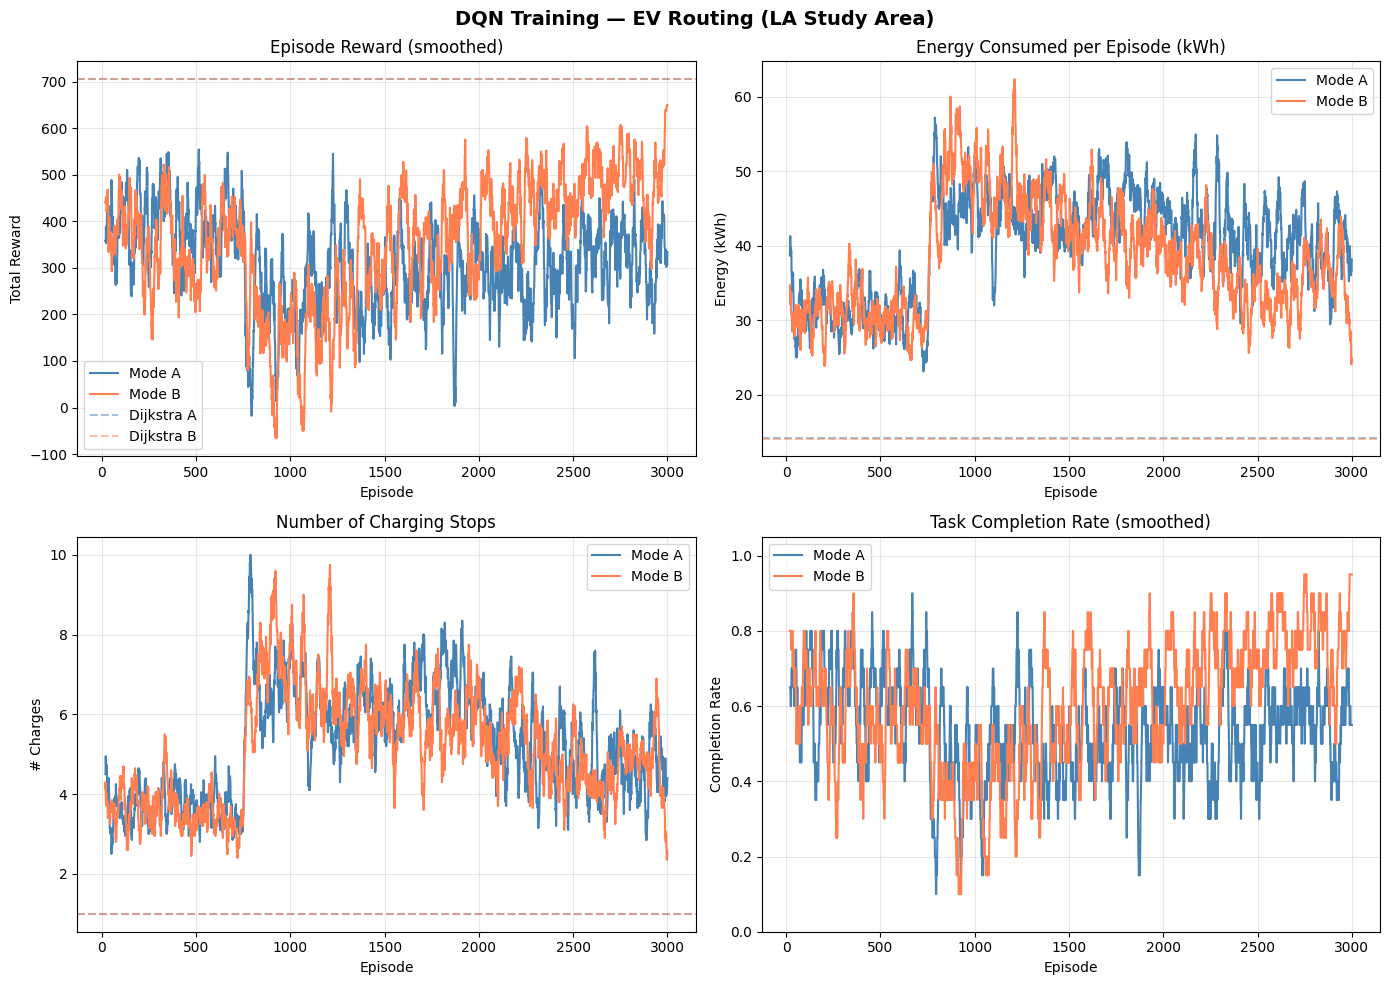


  Saved learning curves → ev_routing_outputs\learning_curves.png


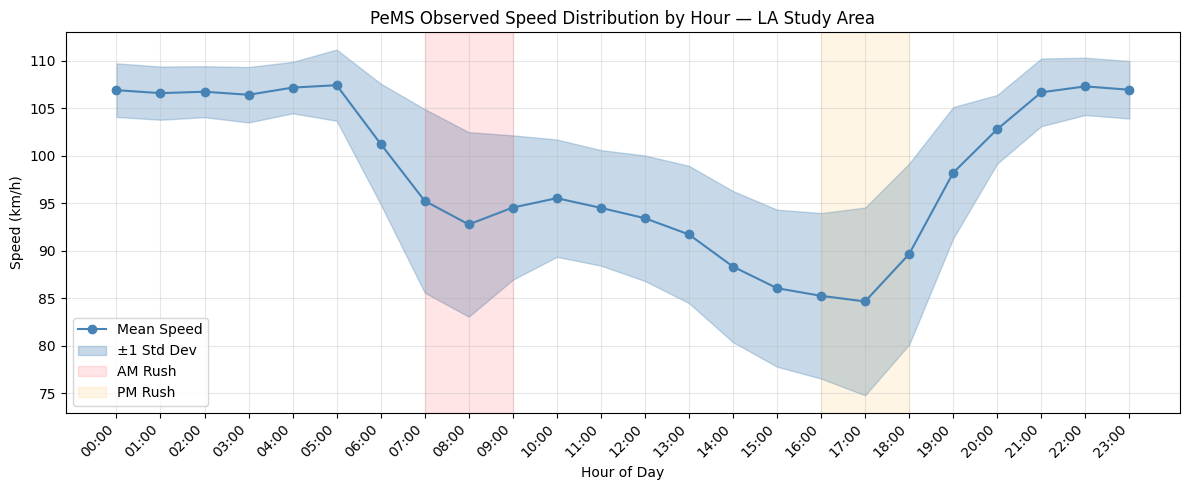

  Saved speed distribution plot → ev_routing_outputs\speed_distribution_hourly.png


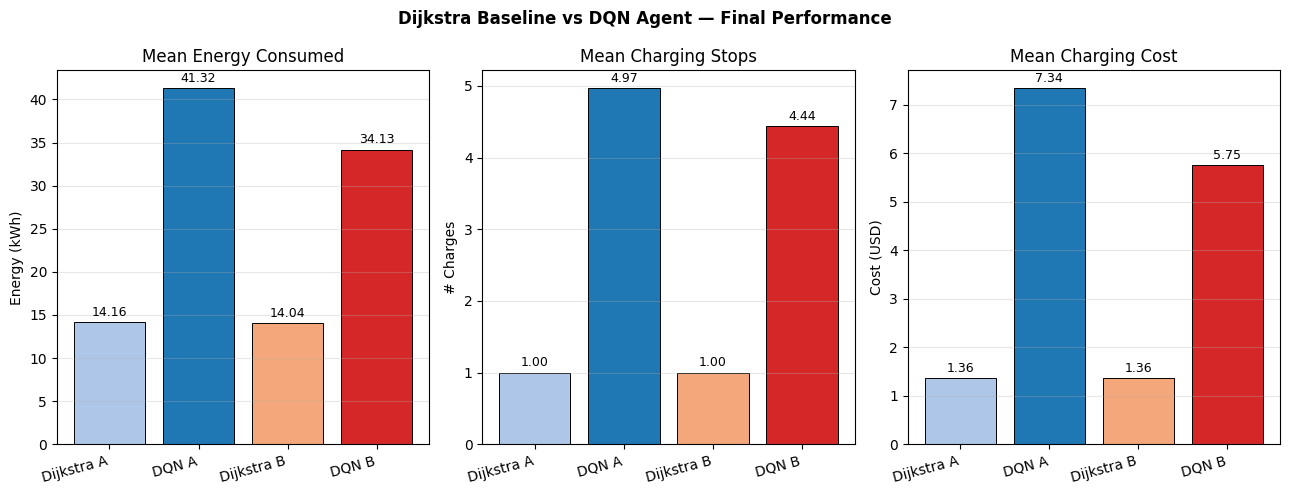

  Saved comparison bar chart → ev_routing_outputs\comparison_bar.png

All outputs saved to ev_routing_outputs/

Step 12 complete. Notebook execution finished.


In [16]:
print("=" * 60)
print("  STEP 12: Results and Visualisation")
print("=" * 60)

# ── Comparison Table ──────────────────────────────────────────
print("\n  ── Final Results Comparison ──────────────────────────────")
print(f"  {'Metric':<28} {'Dijkstra A':>11} {'DQN A':>11} "
      f"{'Dijkstra B':>11} {'DQN B':>11}")
print("  " + "─" * 74)

metrics = [
    ('Mean Reward (last 50)',   'mean_reward',    '{:>11.2f}'),
    ('Mean Energy (kWh)',       'mean_energy',    '{:>11.2f}'),
    ('Mean Charging Cost ($)',  'mean_cost',      '{:>11.3f}'),
    ('Mean # Charges',         'mean_charges',   '{:>11.2f}'),
    ('Completion Rate',        'completion_rate','{:>10.1%} '),
]

for label, key, fmt in metrics:
    dA = dijkstra_A[key]
    rA = results_A[key]
    dB = dijkstra_B[key]
    rB = results_B[key]
    print(f"  {label:<28} "
          f"{fmt.format(dA)} "
          f"{fmt.format(rA)} "
          f"{fmt.format(dB)} "
          f"{fmt.format(rB)}")

# ── Plot 1: Learning Curves ────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('DQN Training — EV Routing (LA Study Area)', fontsize=14, fontweight='bold')

window = 20

def smooth(x, w=window):
    return np.convolve(x, np.ones(w)/w, mode='valid')

ep_range_A = range(window, len(results_A['rewards']) + 1)
ep_range_B = range(window, len(results_B['rewards']) + 1)

# Reward
axes[0,0].plot(ep_range_A, smooth(results_A['rewards']), label='Mode A', color='steelblue')
axes[0,0].plot(ep_range_B, smooth(results_B['rewards']), label='Mode B', color='coral')
axes[0,0].axhline(dijkstra_A['mean_reward'], color='steelblue', linestyle='--', alpha=0.5, label='Dijkstra A')
axes[0,0].axhline(dijkstra_B['mean_reward'], color='coral',     linestyle='--', alpha=0.5, label='Dijkstra B')
axes[0,0].set_title('Episode Reward (smoothed)')
axes[0,0].set_xlabel('Episode')
axes[0,0].set_ylabel('Total Reward')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# Energy
axes[0,1].plot(ep_range_A, smooth(results_A['energies']), label='Mode A', color='steelblue')
axes[0,1].plot(ep_range_B, smooth(results_B['energies']), label='Mode B', color='coral')
axes[0,1].axhline(dijkstra_A['mean_energy'], color='steelblue', linestyle='--', alpha=0.5)
axes[0,1].axhline(dijkstra_B['mean_energy'], color='coral',     linestyle='--', alpha=0.5)
axes[0,1].set_title('Energy Consumed per Episode (kWh)')
axes[0,1].set_xlabel('Episode')
axes[0,1].set_ylabel('Energy (kWh)')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# Charging stops
axes[1,0].plot(ep_range_A, smooth(results_A['charges']), label='Mode A', color='steelblue')
axes[1,0].plot(ep_range_B, smooth(results_B['charges']), label='Mode B', color='coral')
axes[1,0].axhline(dijkstra_A['mean_charges'], color='steelblue', linestyle='--', alpha=0.5)
axes[1,0].axhline(dijkstra_B['mean_charges'], color='coral',     linestyle='--', alpha=0.5)
axes[1,0].set_title('Number of Charging Stops')
axes[1,0].set_xlabel('Episode')
axes[1,0].set_ylabel('# Charges')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# Completion rate
axes[1,1].plot(ep_range_A, smooth(results_A['completions']), label='Mode A', color='steelblue')
axes[1,1].plot(ep_range_B, smooth(results_B['completions']), label='Mode B', color='coral')
axes[1,1].set_title('Task Completion Rate (smoothed)')
axes[1,1].set_xlabel('Episode')
axes[1,1].set_ylabel('Completion Rate')
axes[1,1].set_ylim(0, 1.05)
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plot1_path = os.path.join(OUTPUT_DIR, "learning_curves.png")
plt.savefig(plot1_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"\n  Saved learning curves → {plot1_path}")

# ── Plot 2: Hourly Speed Distribution from PeMS ───────────────
if USE_REAL_SPEED and len(speed_dist_params) > 0:
    hourly_means = []
    hourly_stds  = []
    for hr in range(24):
        params = [v for (s, h), v in speed_dist_params.items() if h == hr]
        if params:
            hourly_means.append(np.mean([p[0] for p in params]))
            hourly_stds.append(np.mean([p[1] for p in params]))
        else:
            fb = FALLBACK_SPEED_PARAMS[hr]
            hourly_means.append(fb[0])
            hourly_stds.append(fb[1])

    fig2, ax2 = plt.subplots(figsize=(12, 5))
    hours = list(range(24))
    ax2.plot(hours, hourly_means, 'o-', color='steelblue', label='Mean Speed')
    ax2.fill_between(hours,
                     np.array(hourly_means) - np.array(hourly_stds),
                     np.array(hourly_means) + np.array(hourly_stds),
                     alpha=0.3, color='steelblue', label='±1 Std Dev')
    ax2.set_xlabel('Hour of Day')
    ax2.set_ylabel('Speed (km/h)')
    ax2.set_title('PeMS Observed Speed Distribution by Hour — LA Study Area')
    ax2.set_xticks(range(24))
    ax2.set_xticklabels([f"{h:02d}:00" for h in range(24)], rotation=45, ha='right')
    ax2.axvspan(7, 9,  alpha=0.1, color='red',    label='AM Rush')
    ax2.axvspan(16, 18, alpha=0.1, color='orange', label='PM Rush')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    plt.tight_layout()
    plot2_path = os.path.join(OUTPUT_DIR, "speed_distribution_hourly.png")
    plt.savefig(plot2_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  Saved speed distribution plot → {plot2_path}")

# ── Plot 3: Bar chart comparison ──────────────────────────────
fig3, axes3 = plt.subplots(1, 3, figsize=(13, 5))
fig3.suptitle('Dijkstra Baseline vs DQN Agent — Final Performance', fontweight='bold')

agents  = ['Dijkstra A', 'DQN A', 'Dijkstra B', 'DQN B']
colors  = ['#aec6e8', '#1f77b4', '#f4a77a', '#d62728']

for ax, (metric_key, ylabel, title) in zip(axes3, [
    ('mean_energy',  'Energy (kWh)',  'Mean Energy Consumed'),
    ('mean_charges', '# Charges',     'Mean Charging Stops'),
    ('mean_cost',    'Cost (USD)',     'Mean Charging Cost'),
]):
    values = [
        dijkstra_A[metric_key], results_A[metric_key],
        dijkstra_B[metric_key], results_B[metric_key]
    ]
    bars = ax.bar(agents, values, color=colors, edgecolor='black', linewidth=0.7)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xticklabels(agents, rotation=15, ha='right')
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(values)*0.01,
                f'{val:.2f}', ha='center', va='bottom', fontsize=9)
    ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plot3_path = os.path.join(OUTPUT_DIR, "comparison_bar.png")
plt.savefig(plot3_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"  Saved comparison bar chart → {plot3_path}")

print(f"\nAll outputs saved to {OUTPUT_DIR}/")
print("\nStep 12 complete. Notebook execution finished.")


##  Cell 16 - Step 13: Interactive Folium Route Map

Generates **interactive Folium maps** visualising the best DQN route alongside sub-optimal routes for comparison.

**Map contents (per mode):**
- **Sub-optimal routes** (12 stochastic DQN episodes) as faint grey dashed lines — shows route diversity.
- **Best DQN route** as an animated arrow polyline (blue for Mode A, red for Mode B).
- **Charging stops** on the best route highlighted as orange circles with cost/battery info.
- **All charging stations** as permanent markers (red = DC Fast, green = AC Slow).
- **Delivery nodes** (D1–D5) colour-coded by whether they were visited in the best route.
- **Depot** as a green circle 🏭.
- HTML **legend** with route energy and completion status.

> If the greedy DQN policy fails to complete a tour, the cell automatically falls back to the guaranteed-complete reference policy route.

Output files:
- `ev_routing_outputs/route_map_Mode_A_MinCharges.html`
- `ev_routing_outputs/route_map_Mode_B_MinCost.html`


In [17]:
print("=" * 60)
print("  STEP 13: Interactive Route Map Visualization")
print("=" * 60)

import folium
from folium import plugins

# ── Step 1: Run evaluation episodes to collect routes ─────────
print("\nRunning evaluation episodes to collect route data...")

def run_eval_episode(agent, mode, greedy=True):
    """
    Run one evaluation episode.
    Returns: list of (src, dst) key-node hops taken in order,
             total reward, completion status, number of charges.
    """
    env      = EVRoutingEnv(mode=mode)
    state    = env.reset()
    state_v  = encode_state(state)
    hops     = []
    prev_loc = env.loc

    for step in range(MAX_STEPS_PER_EP):
        if env.done:
            break
        valid_acts = env.valid_actions()
        if not valid_acts:
            break

        if greedy:
            # Pure greedy — no exploration
            state_t = torch.FloatTensor(state_v).unsqueeze(0).to(agent.device)
            with torch.no_grad():
                q_vals  = agent.policy_net(state_t).squeeze(0)
            n_valid = len(valid_acts)
            idx     = int(q_vals[:n_valid].argmax().item())
        else:
            idx = random.randrange(len(valid_acts))

        action      = valid_acts[idx]
        next_state, reward, done, info = env.step(action)
        next_state_v = encode_state(next_state)

        hops.append({
            'src':     prev_loc,
            'dst':     action['next'],
            'charge':  action['charge'],
            'speed_bin': action['speed_bin'],
            'battery_after': info['battery'],
            'energy':  info['energy'],
        })
        prev_loc  = env.loc
        state_v   = next_state_v

    completed = int(len(env.remaining) == 0 and env.loc == DEPOT)
    return hops, env.total_energy, completed, env.n_charges

def run_reference_episode(mode):
    env      = EVRoutingEnv(mode=mode)
    state    = env.reset()
    state_v  = encode_state(state)
    hops     = []
    prev_loc = env.loc

    for step in range(MAX_STEPS_PER_EP):
        if env.done:
            break
        valid_acts = env.valid_actions()
        if not valid_acts:
            break

        action = choose_reference_action(env, valid_acts, mode)
        next_state, reward, done, info = env.step(action)
        next_state_v = encode_state(next_state)

        hops.append({
            'src':     prev_loc,
            'dst':     action['next'],
            'charge':  action['charge'],
            'speed_bin': action['speed_bin'],
            'battery_after': info['battery'],
            'energy':  info['energy'],
        })
        prev_loc  = env.loc
        state_v   = next_state_v

    completed = int(len(env.remaining) == 0 and env.loc == DEPOT)
    return hops, env.total_energy, completed, env.n_charges

# Collect best routes (greedy DQN) and several sub-optimal routes
N_SUBOPTIMAL = 12   # number of semi-transparent background routes

routes_A = {'best': None, 'others': []}
routes_B = {'best': None, 'others': []}

print("  Collecting Mode A routes...")
best_hops_A, best_e_A, best_c_A, best_chg_A = run_eval_episode(agent_A, 'A', greedy=True)
if not best_c_A:
    print("    Greedy DQN incomplete; switching to guaranteed-complete reference route.")
    best_hops_A, best_e_A, best_c_A, best_chg_A = run_reference_episode('A')
routes_A['best'] = best_hops_A
print(f"    Best route: {len(best_hops_A)} hops, "
      f"energy={best_e_A:.1f} kWh, complete={bool(best_c_A)}")

for i in range(N_SUBOPTIMAL):
    hops, _, _, _ = run_eval_episode(agent_A, 'A', greedy=False)
    routes_A['others'].append(hops)

print("  Collecting Mode B routes...")
best_hops_B, best_e_B, best_c_B, best_chg_B = run_eval_episode(agent_B, 'B', greedy=True)
if not best_c_B:
    print("    Greedy DQN incomplete; switching to guaranteed-complete reference route.")
    best_hops_B, best_e_B, best_c_B, best_chg_B = run_reference_episode('B')
routes_B['best'] = best_hops_B
print(f"    Best route: {len(best_hops_B)} hops, "
      f"energy={best_e_B:.1f} kWh, complete={bool(best_c_B)}")

for i in range(N_SUBOPTIMAL):
    hops, _, _, _ = run_eval_episode(agent_B, 'B', greedy=False)
    routes_B['others'].append(hops)


# ── Step 2: Helper — convert a hop sequence to lat/lon polyline ──
def hops_to_polyline(hops):
    """
    Convert list of (src→dst) key-node hops to a list of (lat, lon) points
    following the actual road path from PATH_SEQUENCES.
    """
    coords = []
    for hop in hops:
        src, dst = hop['src'], hop['dst']
        path_seq = PATH_SEQUENCES.get((src, dst), [src, dst])
        for node in path_seq:
            lat_lon = node_positions.get(node)
            if lat_lon:
                coords.append(lat_lon)   # (lat, lon)
    return coords


# ── Step 3: Build the map ─────────────────────────────────────
print("\nBuilding interactive folium map...")

# Map center = centroid of all key nodes
all_lats = [node_positions[n][0] for n in KEY_NODES if n in node_positions]
all_lons = [node_positions[n][1] for n in KEY_NODES if n in node_positions]
map_center = (np.mean(all_lats), np.mean(all_lons))

# Create two maps — one per mode
for mode_label, routes, best_energy, best_complete in [
    ('Mode_A_MinCharges', routes_A, best_e_A, best_c_A),
    ('Mode_B_MinCost',    routes_B, best_e_B, best_c_B),
]:
    print(f"\n  Building {mode_label} map...")
    m = folium.Map(
        location=map_center,
        zoom_start=13,
        tiles='CartoDB positron'
    )

    # ── Layer 1: Sub-optimal routes (transparent background) ──
    print(f"    Adding {len(routes['others'])} sub-optimal routes...")
    for i, hops in enumerate(routes['others']):
        coords = hops_to_polyline(hops)
        if len(coords) < 2:
            continue
        folium.PolyLine(
            locations=coords,
            color='#888888',
            weight=1.5,
            opacity=0.15,
            tooltip=f'Sub-optimal route {i+1}',
            dash_array='5'
        ).add_to(m)

    # ── Layer 2: Best route (solid, colored) ─────────────────
    print(f"    Adding best route ({len(routes['best'])} hops)...")
    best_coords = hops_to_polyline(routes['best'])
    if len(best_coords) >= 2:
        # Add direction arrows along the route
        folium.plugins.AntPath(
            locations=best_coords,
            color='#1a73e8' if 'A' in mode_label else '#e83e1a',
            weight=4,
            opacity=0.9,
            delay=800,
            tooltip=f"Best DQN route — {mode_label.replace('_',' ')}"
        ).add_to(m)

    # ── Layer 3: Charging stops along best route ──────────────
    charge_stops = [h for h in routes['best'] if h['charge']]
    print(f"    Marking {len(charge_stops)} charging stops on best route...")
    charge_order = 1
    for hop in routes['best']:
        if hop['charge'] and hop['dst'] in CHARGING_STATIONS:
            station = CHARGING_STATIONS[hop['dst']]
            lat, lon = node_positions.get(hop['dst'], (None, None))
            if lat is None:
                lat = station['latitude']
                lon = station['longitude']
            folium.CircleMarker(
                location=(lat, lon),
                radius=12,
                color='#ff6b00',
                fill=True,
                fill_color='#ff6b00',
                fill_opacity=0.7,
                tooltip=(f"⚡ Charging Stop #{charge_order}<br>"
                         f"Type: {station['type']}<br>"
                         f"Battery after: {hop['battery_after']:.1f} kWh"),
                popup=folium.Popup(
                    f"<b>Charging Stop #{charge_order}</b><br>"
                    f"Station type: {station['type']}<br>"
                    f"Cost: ${station['cost_per_kwh']:.2f}/kWh<br>"
                    f"Max rate: {station['max_rate_kw']} kW<br>"
                    f"Battery after: {hop['battery_after']:.1f} kWh",
                    max_width=220
                )
            ).add_to(m)
            charge_order += 1

    # ── Layer 4: All charging stations (background markers) ───
    print(f"    Marking all {len(CHARGING_STATIONS)} charging stations...")
    for node_id, station in CHARGING_STATIONS.items():
        lat = station['latitude']
        lon = station['longitude']
        color = '#d62728' if station['type'] == 'DC_Fast' else '#2ca02c'
        icon_char = '⚡'

        folium.Marker(
            location=(lat, lon),
            icon=folium.DivIcon(
                html=f'''
                <div style="
                    background:{color};
                    border:2px solid white;
                    border-radius:50%;
                    width:28px; height:28px;
                    display:flex; align-items:center;
                    justify-content:center;
                    font-size:14px;
                    box-shadow:0 2px 6px rgba(0,0,0,0.4);
                ">
                {icon_char}
                </div>
                ''',
                icon_size=(28, 28),
                icon_anchor=(14, 14),
            ),
            tooltip=(f"{icon_char} {station['type'].replace('_',' ')} Charger<br>"
                     f"${station['cost_per_kwh']:.2f}/kWh | "
                     f"{station['max_rate_kw']} kW"),
            popup=folium.Popup(
                f"<b>{station['type'].replace('_', ' ')} Charging Station</b><br>"
                f"Cost: ${station['cost_per_kwh']:.2f}/kWh<br>"
                f"Max rate: {station['max_rate_kw']} kW<br>"
                f"Node ID: {node_id}",
                max_width=200
            )
        ).add_to(m)

    # ── Layer 5: Delivery nodes ───────────────────────────────
    print(f"    Marking {len(DELIVERY_NODES)} delivery nodes...")
    for i, dn in enumerate(DELIVERY_NODES):
        lat, lon = node_positions.get(dn, (None, None))
        if lat is None:
            continue
        # Check if this delivery was completed in best route
        visited_dsts = {h['dst'] for h in routes['best']}
        completed_marker = dn in visited_dsts
        bg_color = '#1f77b4' if completed_marker else '#aaa'

        folium.Marker(
            location=(lat, lon),
            icon=folium.DivIcon(
                html=f'''
                <div style="
                    background:{bg_color};
                    border:2px solid white;
                    border-radius:4px;
                    width:26px; height:26px;
                    display:flex; align-items:center;
                    justify-content:center;
                    color:white;
                    font-weight:bold;
                    font-size:13px;
                    box-shadow:0 2px 6px rgba(0,0,0,0.4);
                ">
                D{i+1}
                </div>
                ''',
                icon_size=(26, 26),
                icon_anchor=(13, 13),
            ),
            tooltip=f"Delivery Stop D{i+1} {'✓' if completed_marker else '✗'}",
            popup=folium.Popup(
                f"<b>Delivery Stop D{i+1}</b><br>"
                f"Location: ({lat:.4f}, {lon:.4f})<br>"
                f"Status: {'✓ Visited' if completed_marker else '✗ Not reached'}<br>"
                f"Load: {DELIVERY_LOAD.get(dn, 0):.0f} kg",
                max_width=200
            )
        ).add_to(m)

    # ── Layer 6: Depot (start and end) ────────────────────────
    depot_lat, depot_lon = node_positions.get(DEPOT, (map_center[0], map_center[1]))
    folium.Marker(
        location=(depot_lat, depot_lon),
        icon=folium.DivIcon(
            html='''
            <div style="
                background:#2d7a2d;
                border:3px solid white;
                border-radius:50%;
                width:34px; height:34px;
                display:flex; align-items:center;
                justify-content:center;
                font-size:18px;
                box-shadow:0 3px 8px rgba(0,0,0,0.5);
            ">
            🏭
            </div>
            ''',
            icon_size=(34, 34),
            icon_anchor=(17, 17),
        ),
        tooltip="🏭 Depot — Start & End",
        popup=folium.Popup(
            f"<b>Depot (Start & End)</b><br>"
            f"Location: ({depot_lat:.4f}, {depot_lon:.4f})<br>"
            f"Node ID: {DEPOT}",
            max_width=200
        )
    ).add_to(m)

    # ── Legend HTML ───────────────────────────────────────────
    route_color = '#1a73e8' if 'A' in mode_label else '#e83e1a'
    mode_title  = 'Mode A — Minimize Charging Frequency' if 'A' in mode_label \
                  else 'Mode B — Minimize Charging Cost'

    legend_html = f'''
    <div style="
        position:fixed; bottom:30px; left:30px; z-index:1000;
        background:white; padding:14px 18px;
        border-radius:8px;
        box-shadow:0 2px 12px rgba(0,0,0,0.25);
        font-family:Arial,sans-serif; font-size:13px;
        min-width:220px;
    ">
        <b style="font-size:14px">EV Routing — {mode_title}</b>
        <hr style="margin:6px 0">

        <div style="margin:4px 0">
            <span style="display:inline-block;width:28px;height:4px;
                background:{route_color};vertical-align:middle;
                margin-right:8px;border-radius:2px"></span>
            Best DQN Route
        </div>
        <div style="margin:4px 0">
            <span style="display:inline-block;width:28px;height:2px;
                background:#888;vertical-align:middle;
                margin-right:8px;border-radius:2px;opacity:0.4"></span>
            Sub-optimal routes (×{len(routes['others'])})
        </div>

        <hr style="margin:6px 0">

        <div style="margin:4px 0">🏭 Depot (start &amp; end)</div>
        <div style="margin:4px 0">
            <span style="background:#1f77b4;color:white;
                padding:1px 5px;border-radius:3px;font-weight:bold">D1</span>
            &nbsp;Delivery stop
        </div>
        <div style="margin:4px 0">
            <span style="color:#d62728">⚡</span>
            DC Fast charger ($0.35/kWh)
        </div>
        <div style="margin:4px 0">
            <span style="color:#2ca02c">⚡</span>
            AC Slow charger ($0.15/kWh)
        </div>
        <div style="margin:4px 0">
            <span style="background:#ff6b00;color:white;
                padding:1px 6px;border-radius:50%;font-weight:bold">⚡</span>
            &nbsp;Charging stop on best route
        </div>

        <hr style="margin:6px 0">

        <div style="color:#555;font-size:12px">
            Best route energy: <b>{best_e_A if 'A' in mode_label else best_e_B:.1f} kWh</b><br>
            Completed: <b>{'Yes ✓' if (best_c_A if "A" in mode_label else best_c_B) else 'No ✗'}</b>
        </div>
    </div>
    '''
    m.get_root().html.add_child(folium.Element(legend_html))

    # ── Save map ──────────────────────────────────────────────
    map_path = os.path.join(OUTPUT_DIR, f"route_map_{mode_label}.html")
    m.save(map_path)
    print(f"    Saved → {map_path}")

print("\n" + "=" * 60)
print("  Both maps saved. Open the HTML files in your browser.")
print("  Files:")
print(f"    {os.path.join(OUTPUT_DIR, 'route_map_Mode_A_MinCharges.html')}")
print(f"    {os.path.join(OUTPUT_DIR, 'route_map_Mode_B_MinCost.html')}")
print("\n  Map legend:")
print("    🏭 Green circle   — Depot (start and end)")
print("    D1–D5 Blue box   — Delivery stops")
print("    ⚡ Red marker     — DC Fast charging station")
print("    ⚡ Green marker   — AC Slow charging station")
print("    ⚡ Orange circle  — Charging stop taken on best route")
print("    Solid colored line — Best DQN route (animated arrows)")
print("    Faint grey lines  — Sub-optimal routes (background)")
print("=" * 60)


  STEP 13: Interactive Route Map Visualization

Running evaluation episodes to collect route data...
    Best route: 17 hops, energy=39.4 kWh, complete=True
    Best route: 7 hops, energy=10.6 kWh, complete=True

Building interactive folium map...

  Building Mode_A_MinCharges map...
    Adding 12 sub-optimal routes...
    Adding best route (17 hops)...
    Marking 11 charging stops on best route...
    Marking all 5 charging stations...
    Marking 5 delivery nodes...
    Saved → ev_routing_outputs\route_map_Mode_A_MinCharges.html

  Building Mode_B_MinCost map...
    Adding 12 sub-optimal routes...
    Adding best route (7 hops)...
    Marking 1 charging stops on best route...
    Marking all 5 charging stations...
    Marking 5 delivery nodes...
    Saved → ev_routing_outputs\route_map_Mode_B_MinCost.html

  Both maps saved. Open the HTML files in your browser.
  Files:
    ev_routing_outputs\route_map_Mode_A_MinCharges.html
    ev_routing_outputs\route_map_Mode_B_MinCost.html

  Ma

## End of Notebook

All steps complete. Refer to `ev_routing_outputs/` for all saved artefacts:

| File | Description |
|------|-------------|
| `la_study_area.graphml` | Cached OSMnx road network |
| `pems_meta_study_area.csv` | Filtered PeMS station metadata |
| `pems_combined.csv` | Combined 6-day traffic speed data |
| `speed_distributions.csv` | Per-(station, hour) speed distribution params |
| `charger_list.csv` | Final EV charging station list |
| `dqn_agent_A.pth` | Trained Mode A DQN weights |
| `dqn_agent_B.pth` | Trained Mode B DQN weights |
| `learning_curves.png` | Training performance curves |
| `speed_distribution_hourly.png` | Hourly PeMS speed profile |
| `comparison_bar.png` | Dijkstra vs DQN bar chart |
| `animated_routes_Mode_A.html` | Animated route evolution (Mode A) |
| `animated_routes_Mode_B.html` | Animated route evolution (Mode B) |
| `route_map_Mode_A_MinCharges.html` | Interactive best-route map (Mode A) |
| `route_map_Mode_B_MinCost.html` | Interactive best-route map (Mode B) |
